# Settings

In [1]:
library(dplyr)
library(stringr)
library(tidyr)
library(Seurat)
library(Signac)
library(DESeq2)
library(ggplot2)
library(ggrepel)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘DESeq2’ was built under R version 4.3.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package 

# PCA

In [5]:
meta = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/H3K27me3.meta.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Fibrosis.stage,Fat.distribution,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>
1,HL150001,5,18,84,514,22,0,71,15,0,⋯,0,Centrizonal,0,0,0,0,1,M,47,27.1
2,HL150009,5,9,80,713,66,0,83,6,3,⋯,0,centrizonal,0,0,0,0,1,M,37,29.4


[1] "donor_demux"          "B"                    "Cholangiocyte"       
 [4] "Endothelial"          "Hepatocytes"          "HSC"                 
 [7] "Mast"                 "Myeloid"              "NK"                  
[10] "Schwann"              "T"                    "batch"               
[13] "disease_status"       "condition"            "Steatosis.grade"     
[16] "Fibrosis.stage"       "Fat.distribution"     "Lobular.inflammation"
[19] "Ballooning"           "Portal.inflammation"  "Hepatocyte.necrosis" 
[22] "MASH.CRN.score..X.8"  "Gender"               "Age"                 
[25] "BMI"

In [6]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/bins_mtx/'
#Create outdir for results
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/'
dir.create(outdir)
# dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_H3K27me3_donor.15kb_bin.rpm.xls')
#Cut off file suffices to get celltype names
cells <- gsub('_H3K27me3_donor.15kb_bin.rpm.xls','', files)

files
cells

Warning message in dir.create(outdir):
“'/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins' already exists”


[1] "B_H3K27me3_donor.15kb_bin.rpm.xls"            
 [2] "Cholangiocyte_H3K27me3_donor.15kb_bin.rpm.xls"
 [3] "Endothelial_H3K27me3_donor.15kb_bin.rpm.xls"  
 [4] "Hepatocytes_H3K27me3_donor.15kb_bin.rpm.xls"  
 [5] "HSC_H3K27me3_donor.15kb_bin.rpm.xls"          
 [6] "Mast_H3K27me3_donor.15kb_bin.rpm.xls"         
 [7] "Myeloid_H3K27me3_donor.15kb_bin.rpm.xls"      
 [8] "NK_H3K27me3_donor.15kb_bin.rpm.xls"           
 [9] "Schwann_H3K27me3_donor.15kb_bin.rpm.xls"      
[10] "T_H3K27me3_donor.15kb_bin.rpm.xls"

[1] "B"             "Cholangiocyte" "Endothelial"   "Hepatocytes"  
 [5] "HSC"           "Mast"          "Myeloid"       "NK"           
 [9] "Schwann"       "T"

[1] "Analyzing: B"
[1] 183028     37


Donors detectected with celltype: 37

subsetting metadata accordingly - Check that value is equal to above: 37

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


[1] "Analyzing: Cholangiocyte"
[1] 183028     83


Donors detectected with celltype: 83

subsetting metadata accordingly - Check that value is equal to above: 83

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

using ntop=500 top features by variance

Warning message:
“ggrepel: 62 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Endothelial"
[1] 183028     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

using ntop=500 top features by variance



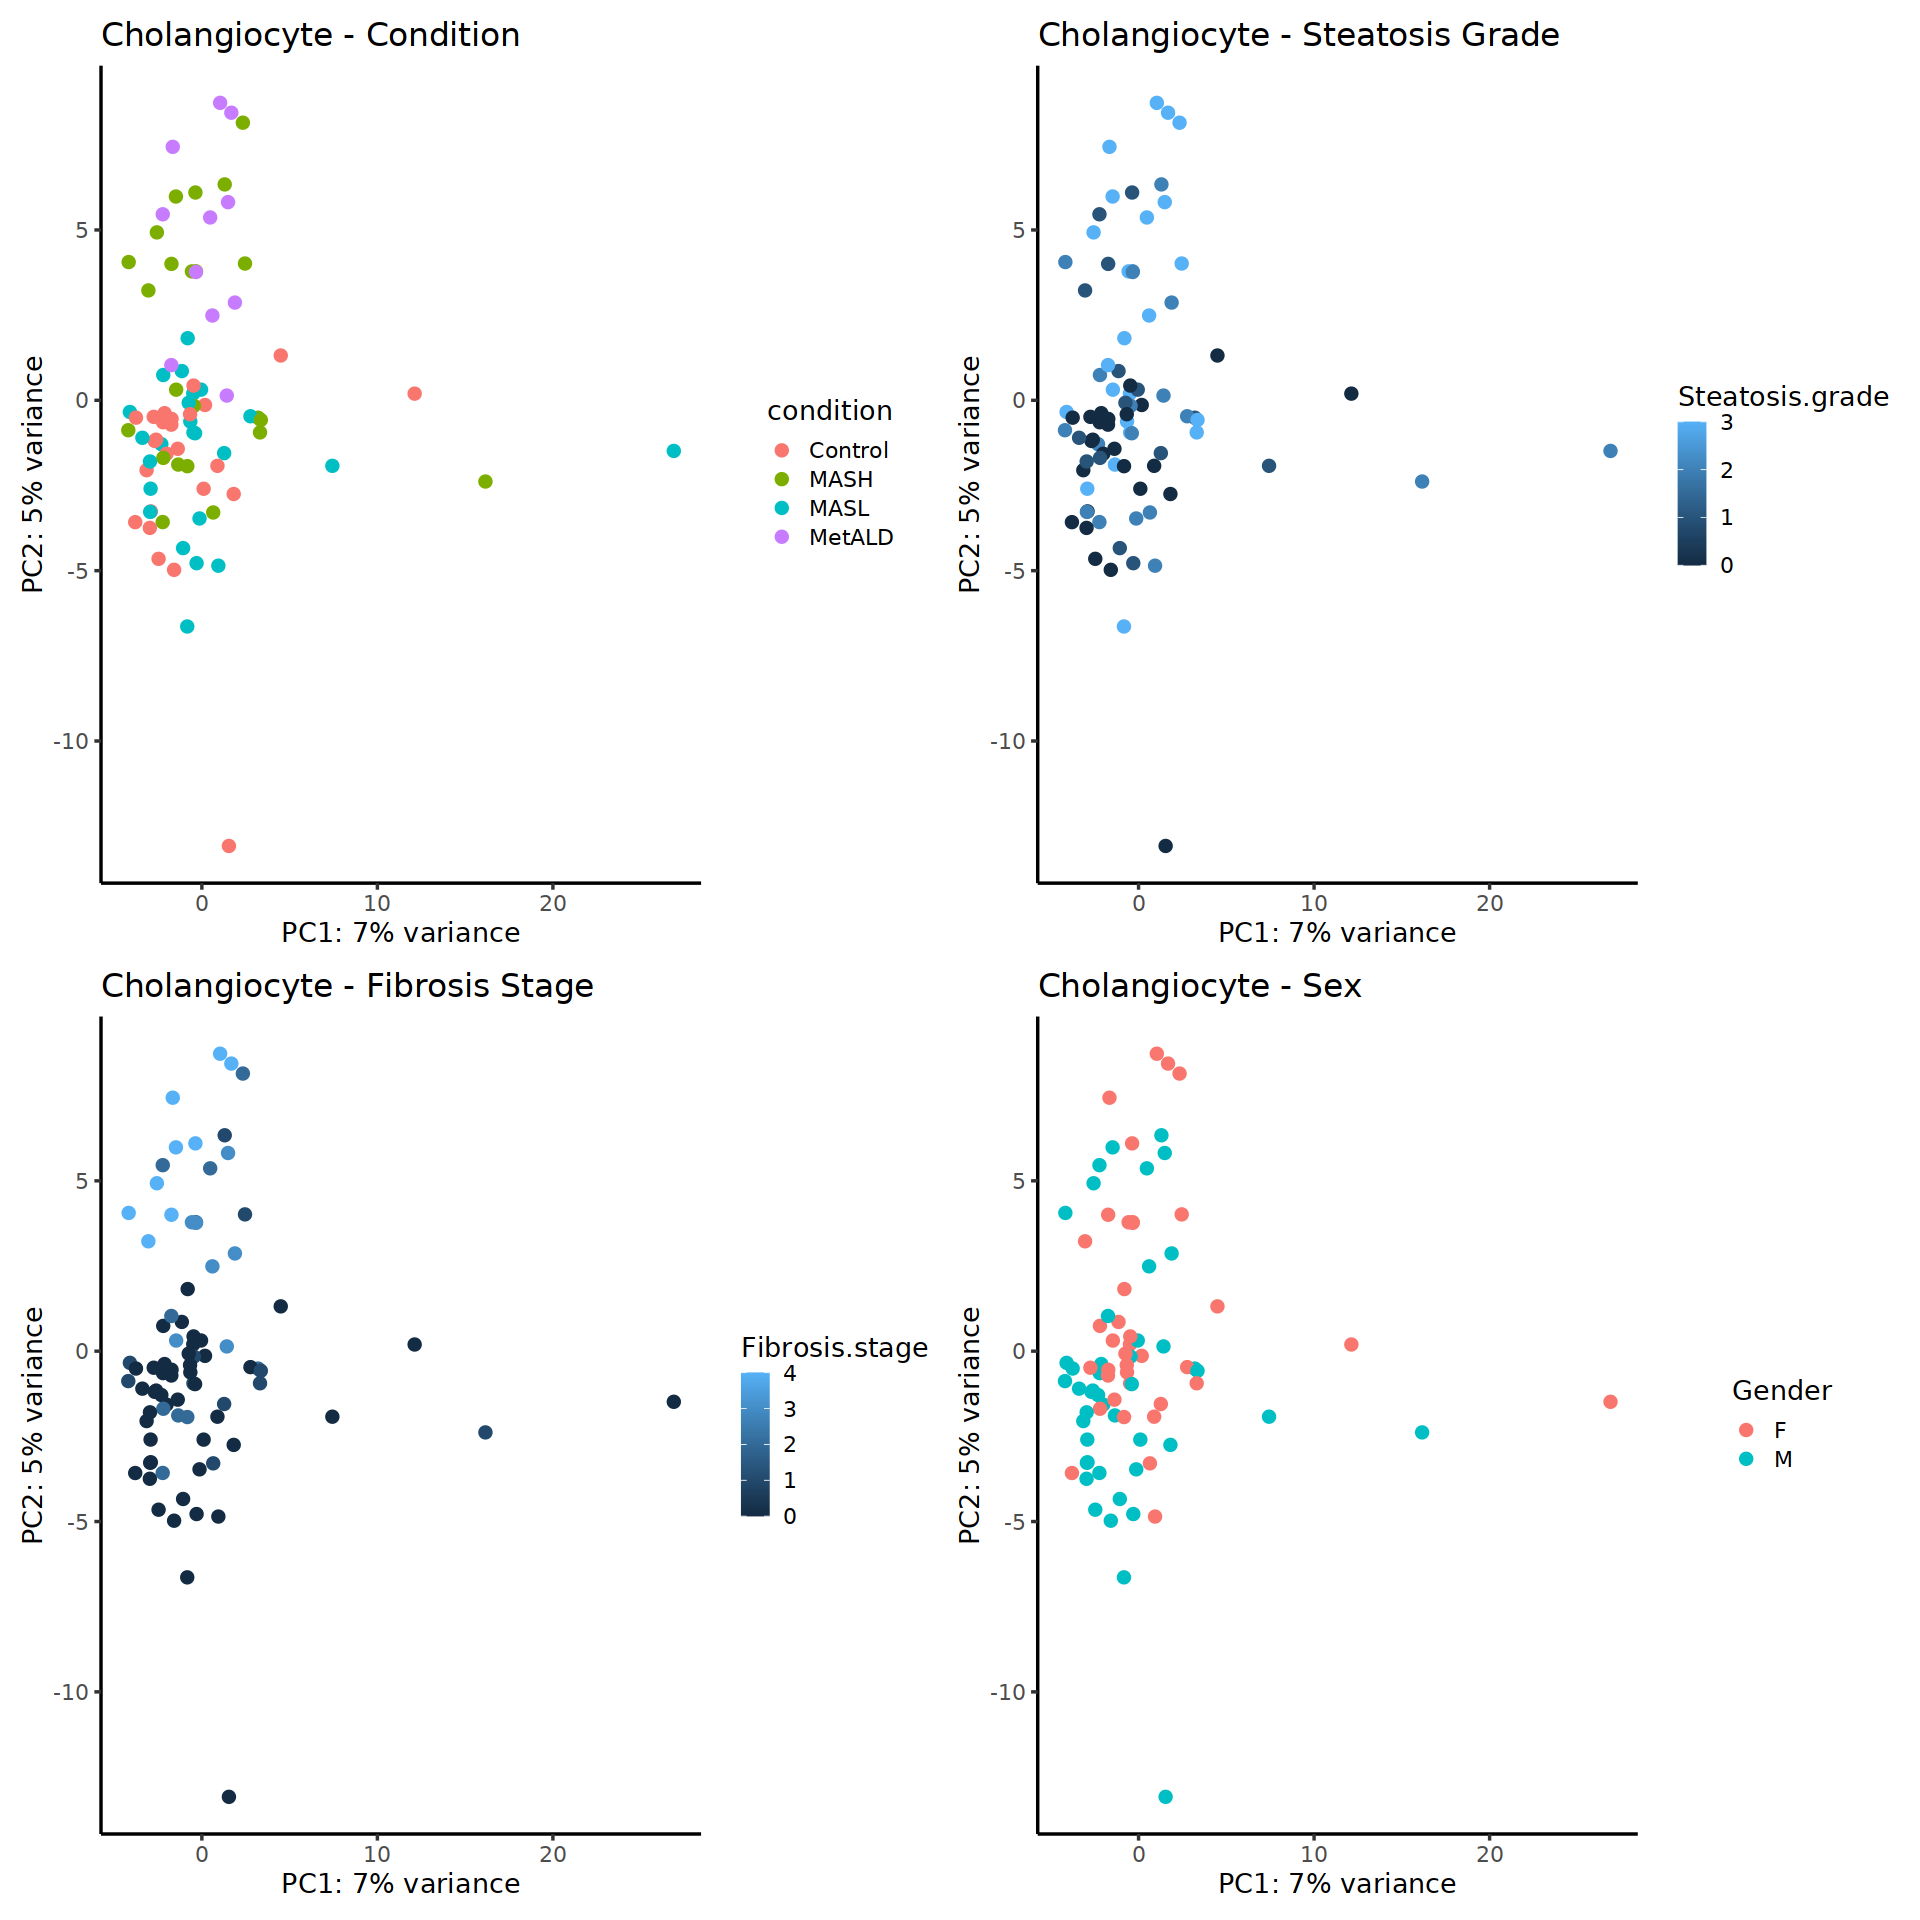

Warning message:
“ggrepel: 9 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


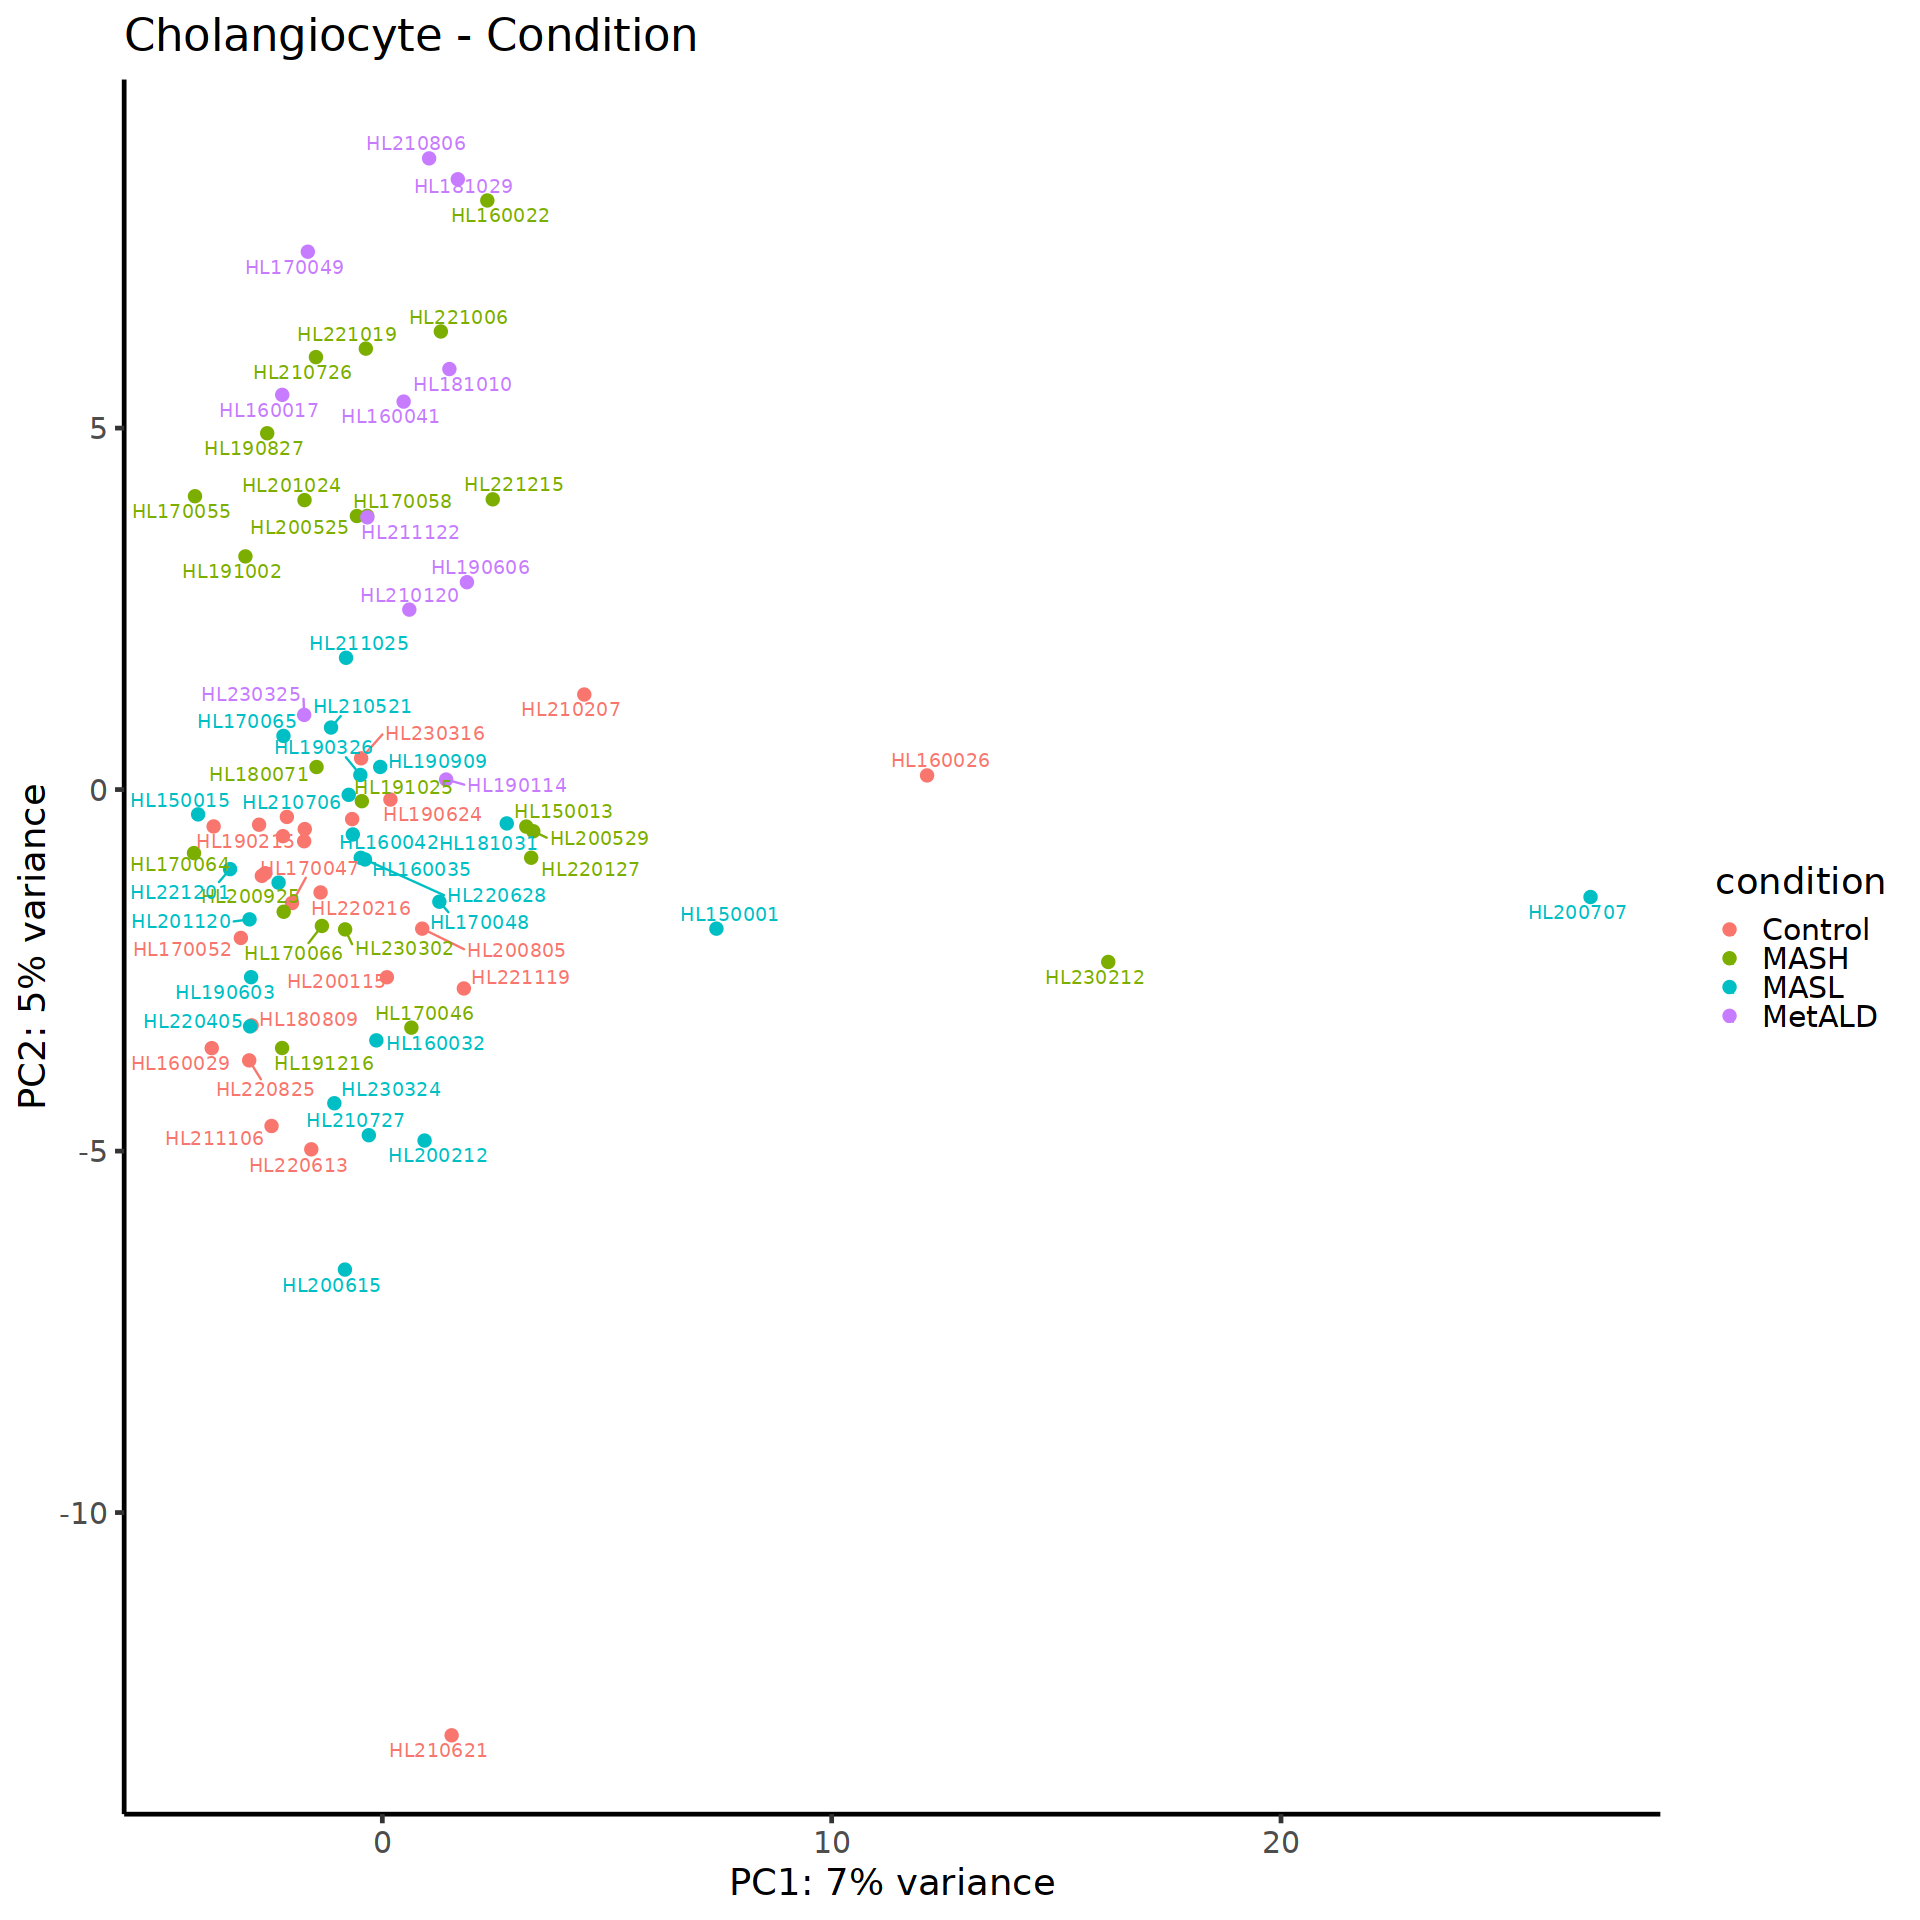

Warning message:
“ggrepel: 77 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes"
[1] 183028     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

using ntop=500 top features by variance



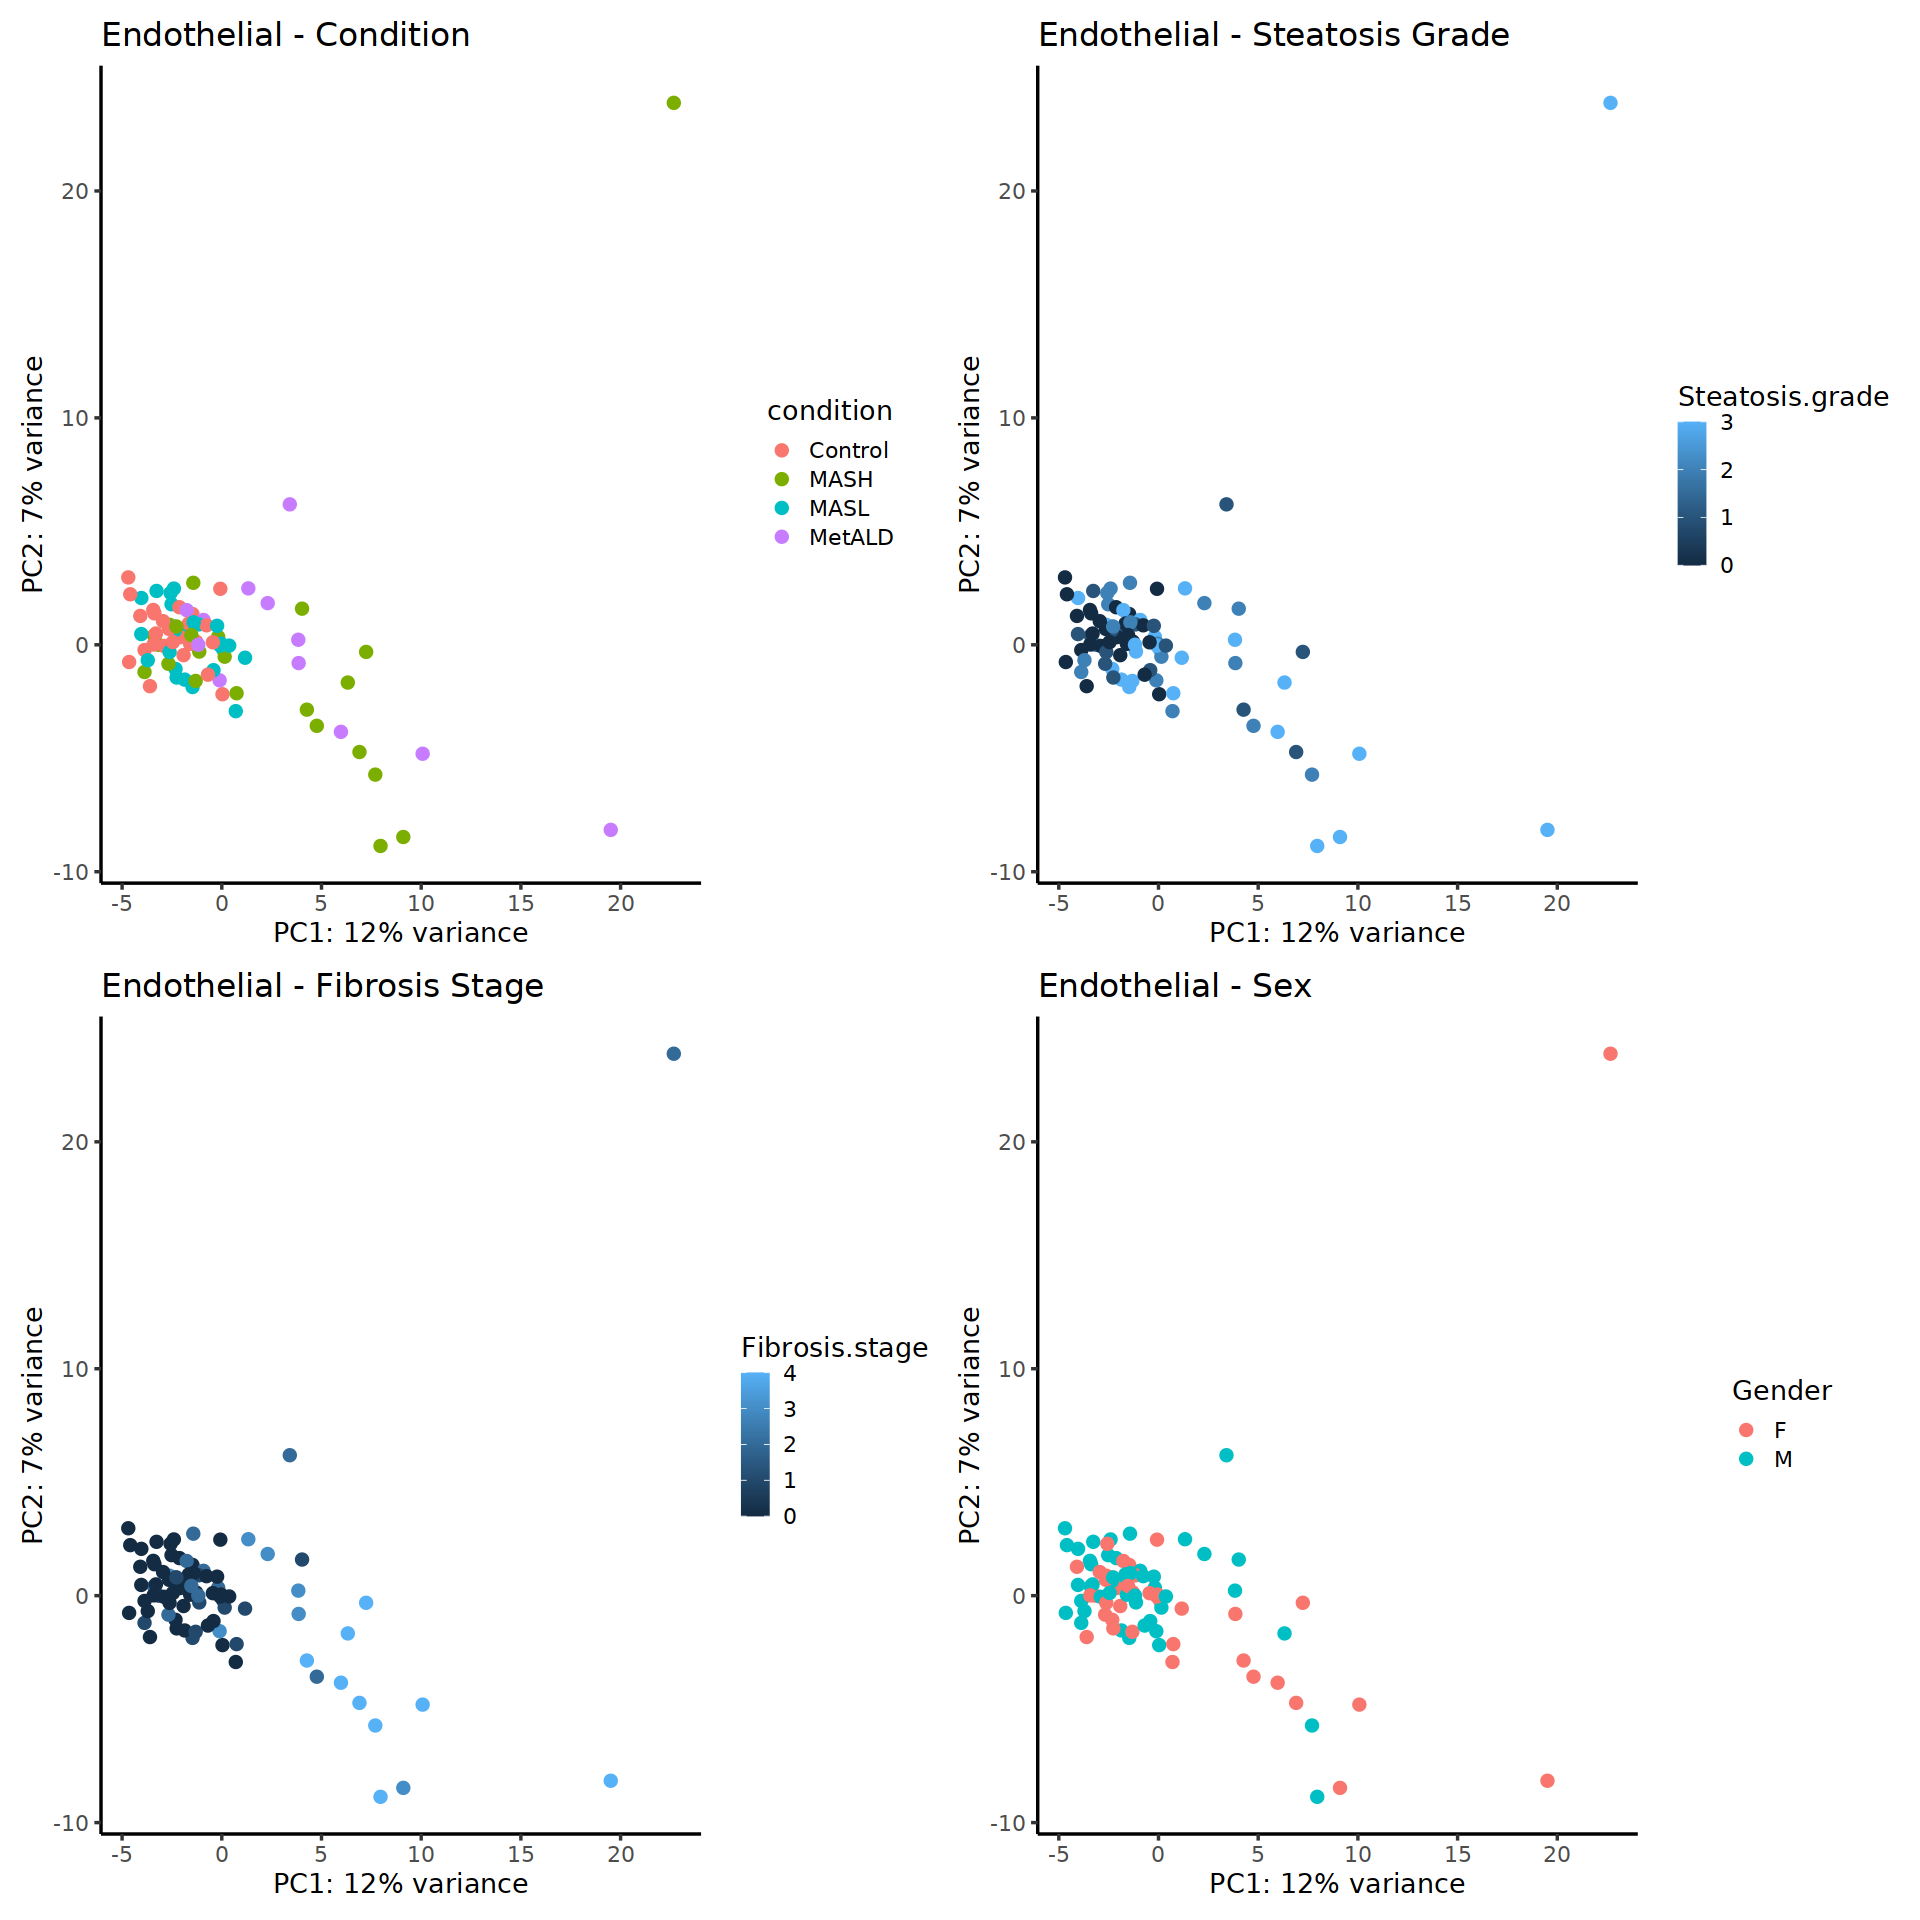

Warning message:
“ggrepel: 45 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


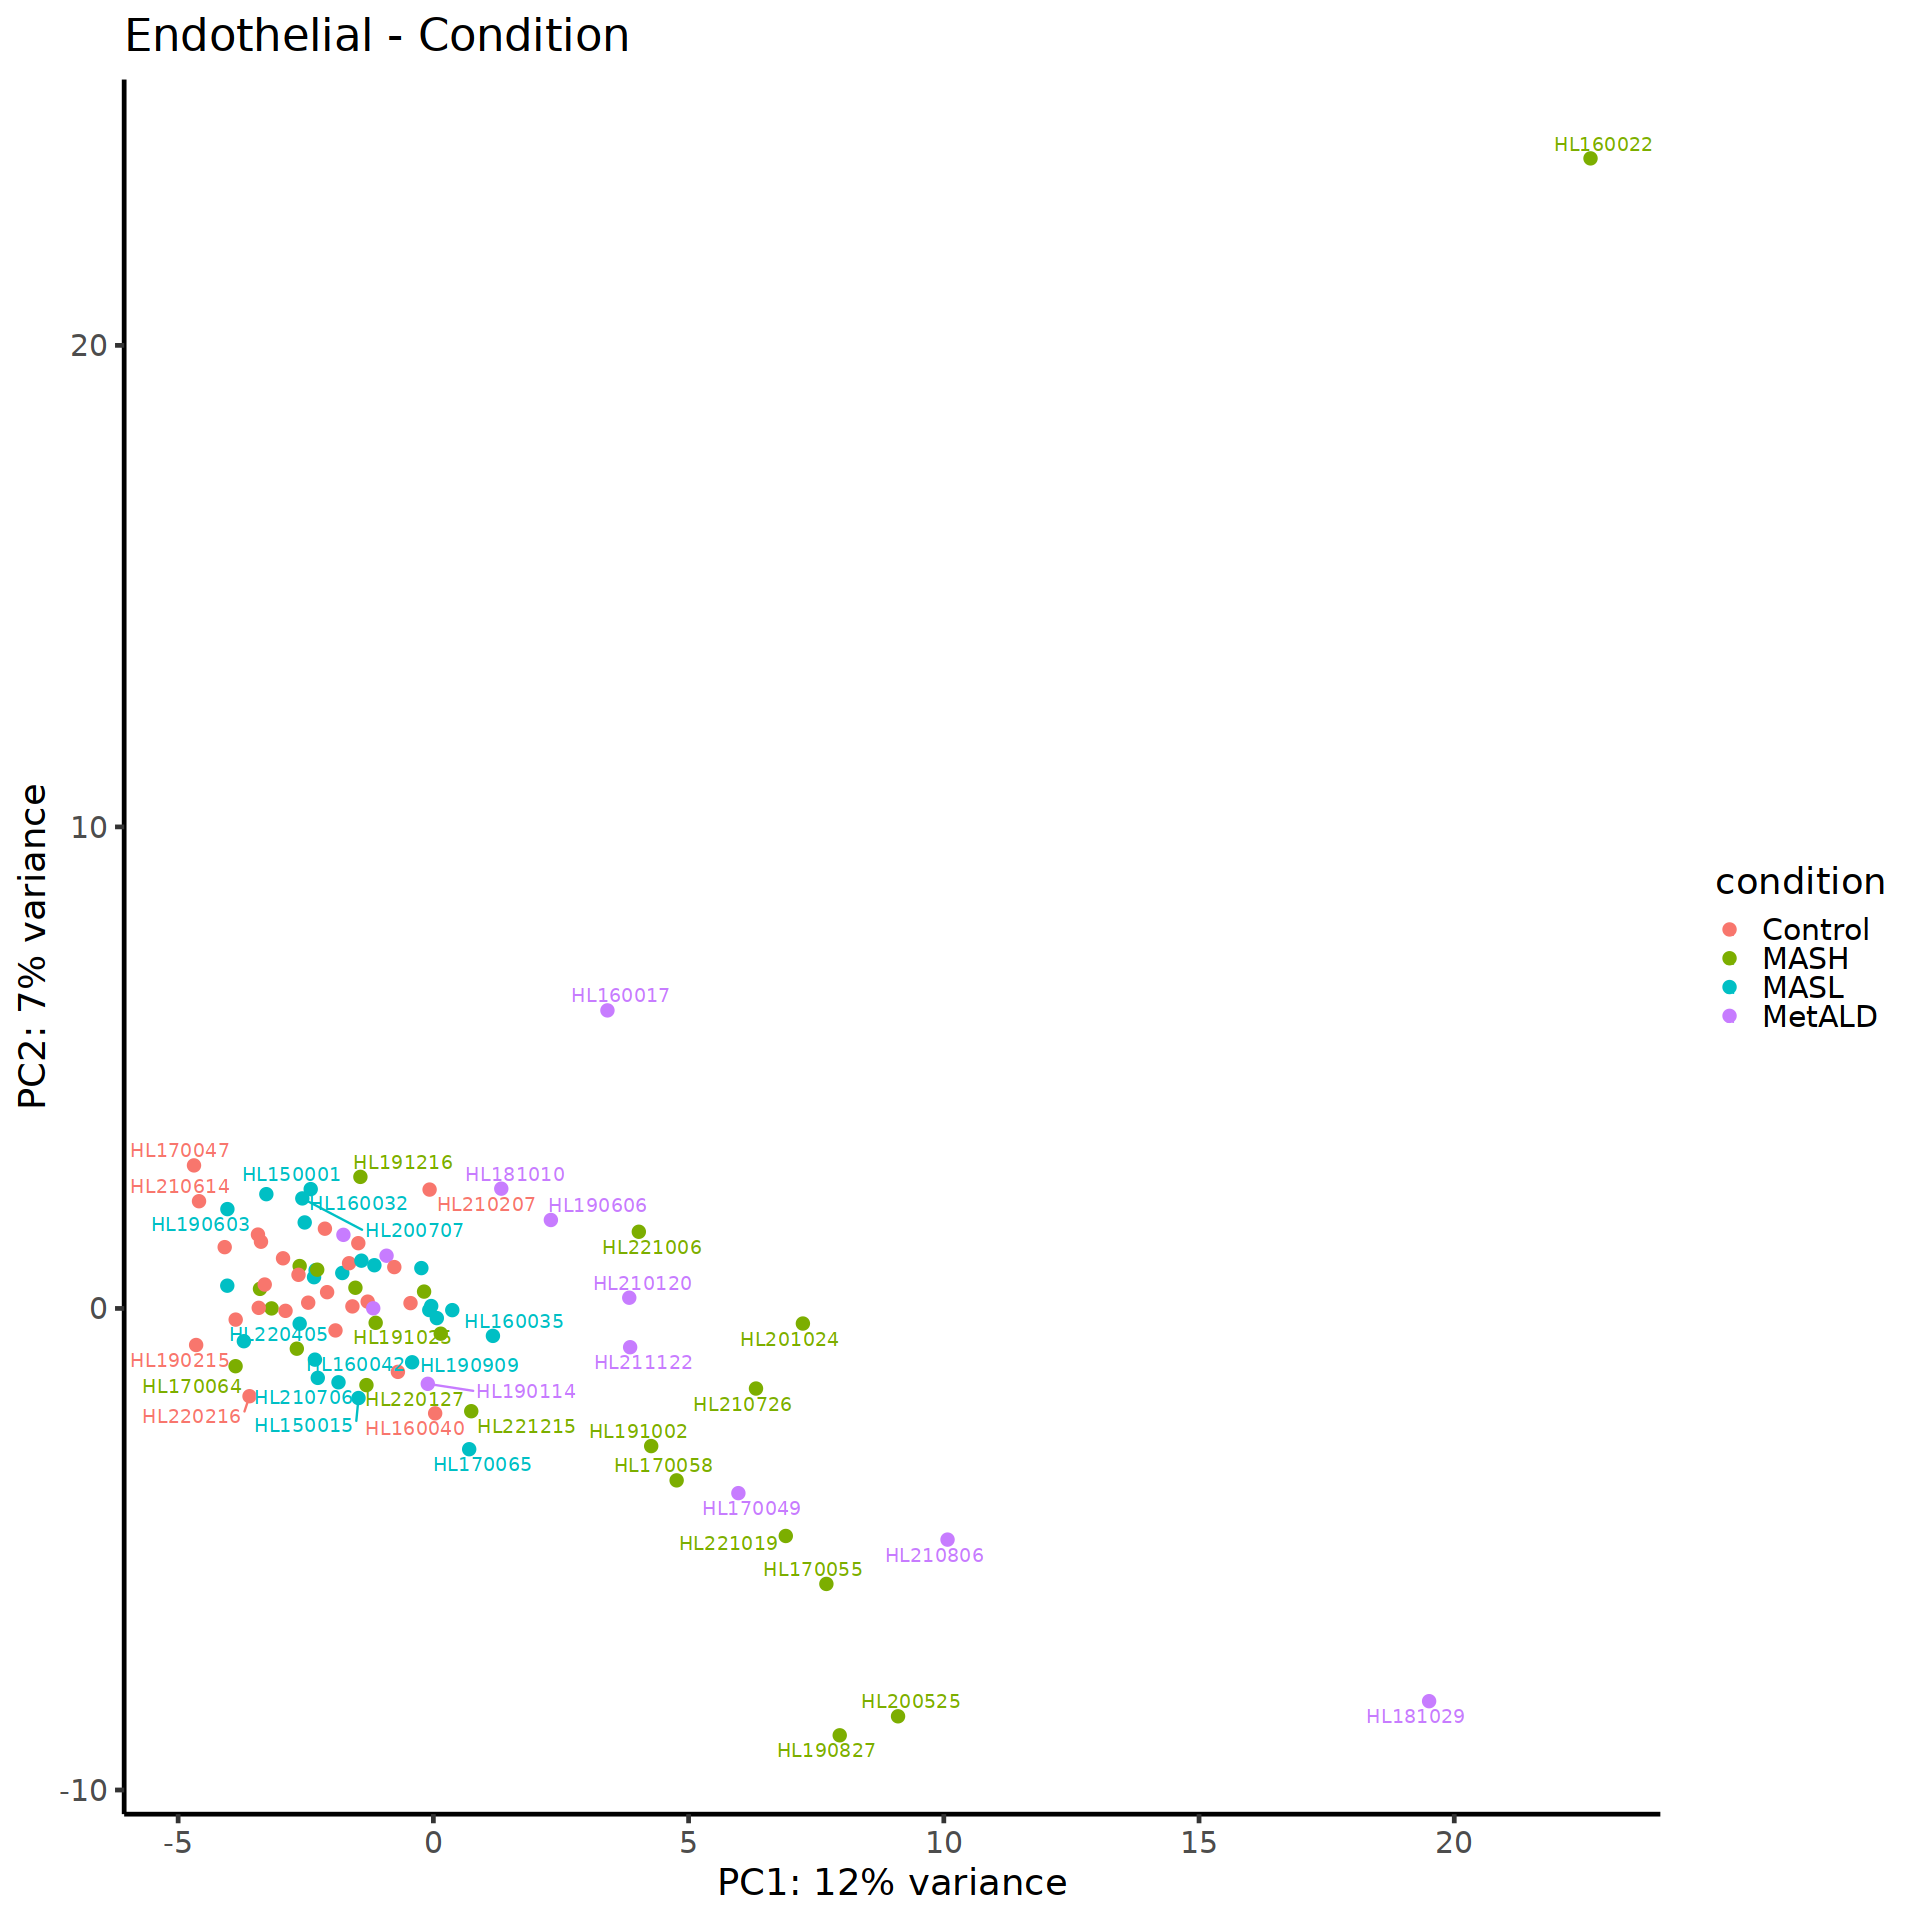

Warning message:
“ggrepel: 29 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: HSC"
[1] 183028     84


Donors detectected with celltype: 84

subsetting metadata accordingly - Check that value is equal to above: 84

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

using ntop=500 top features by variance



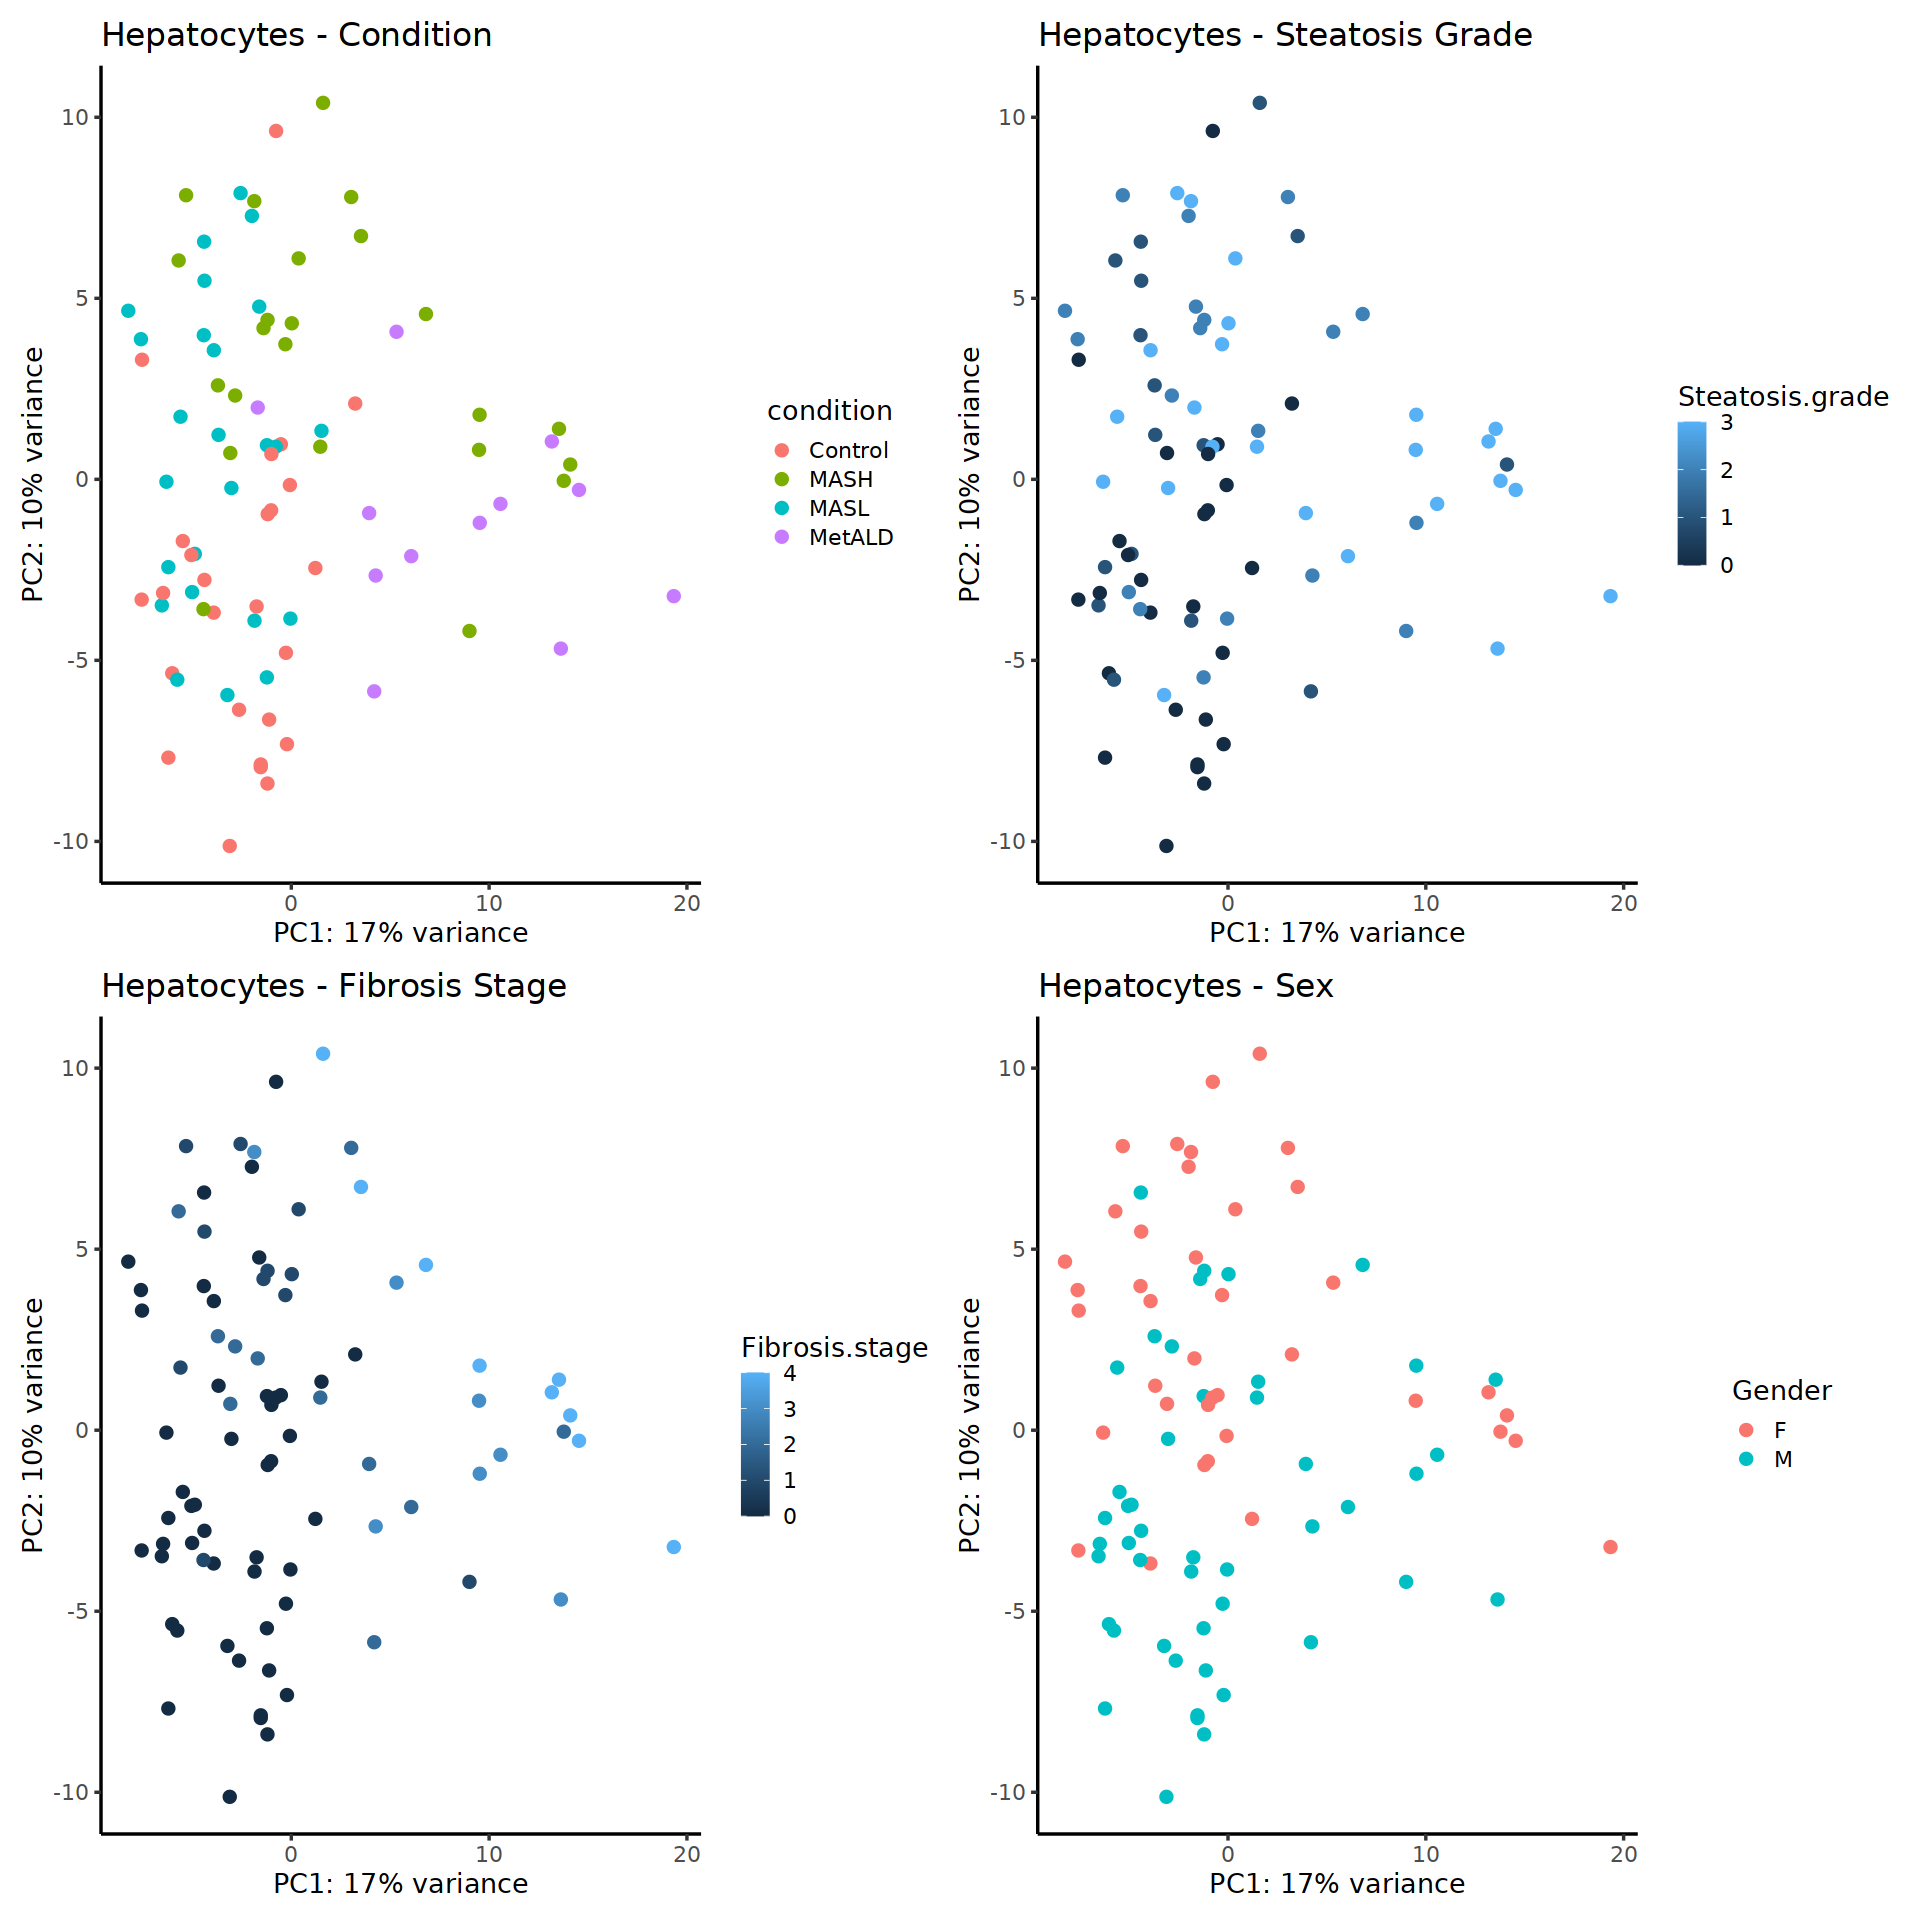

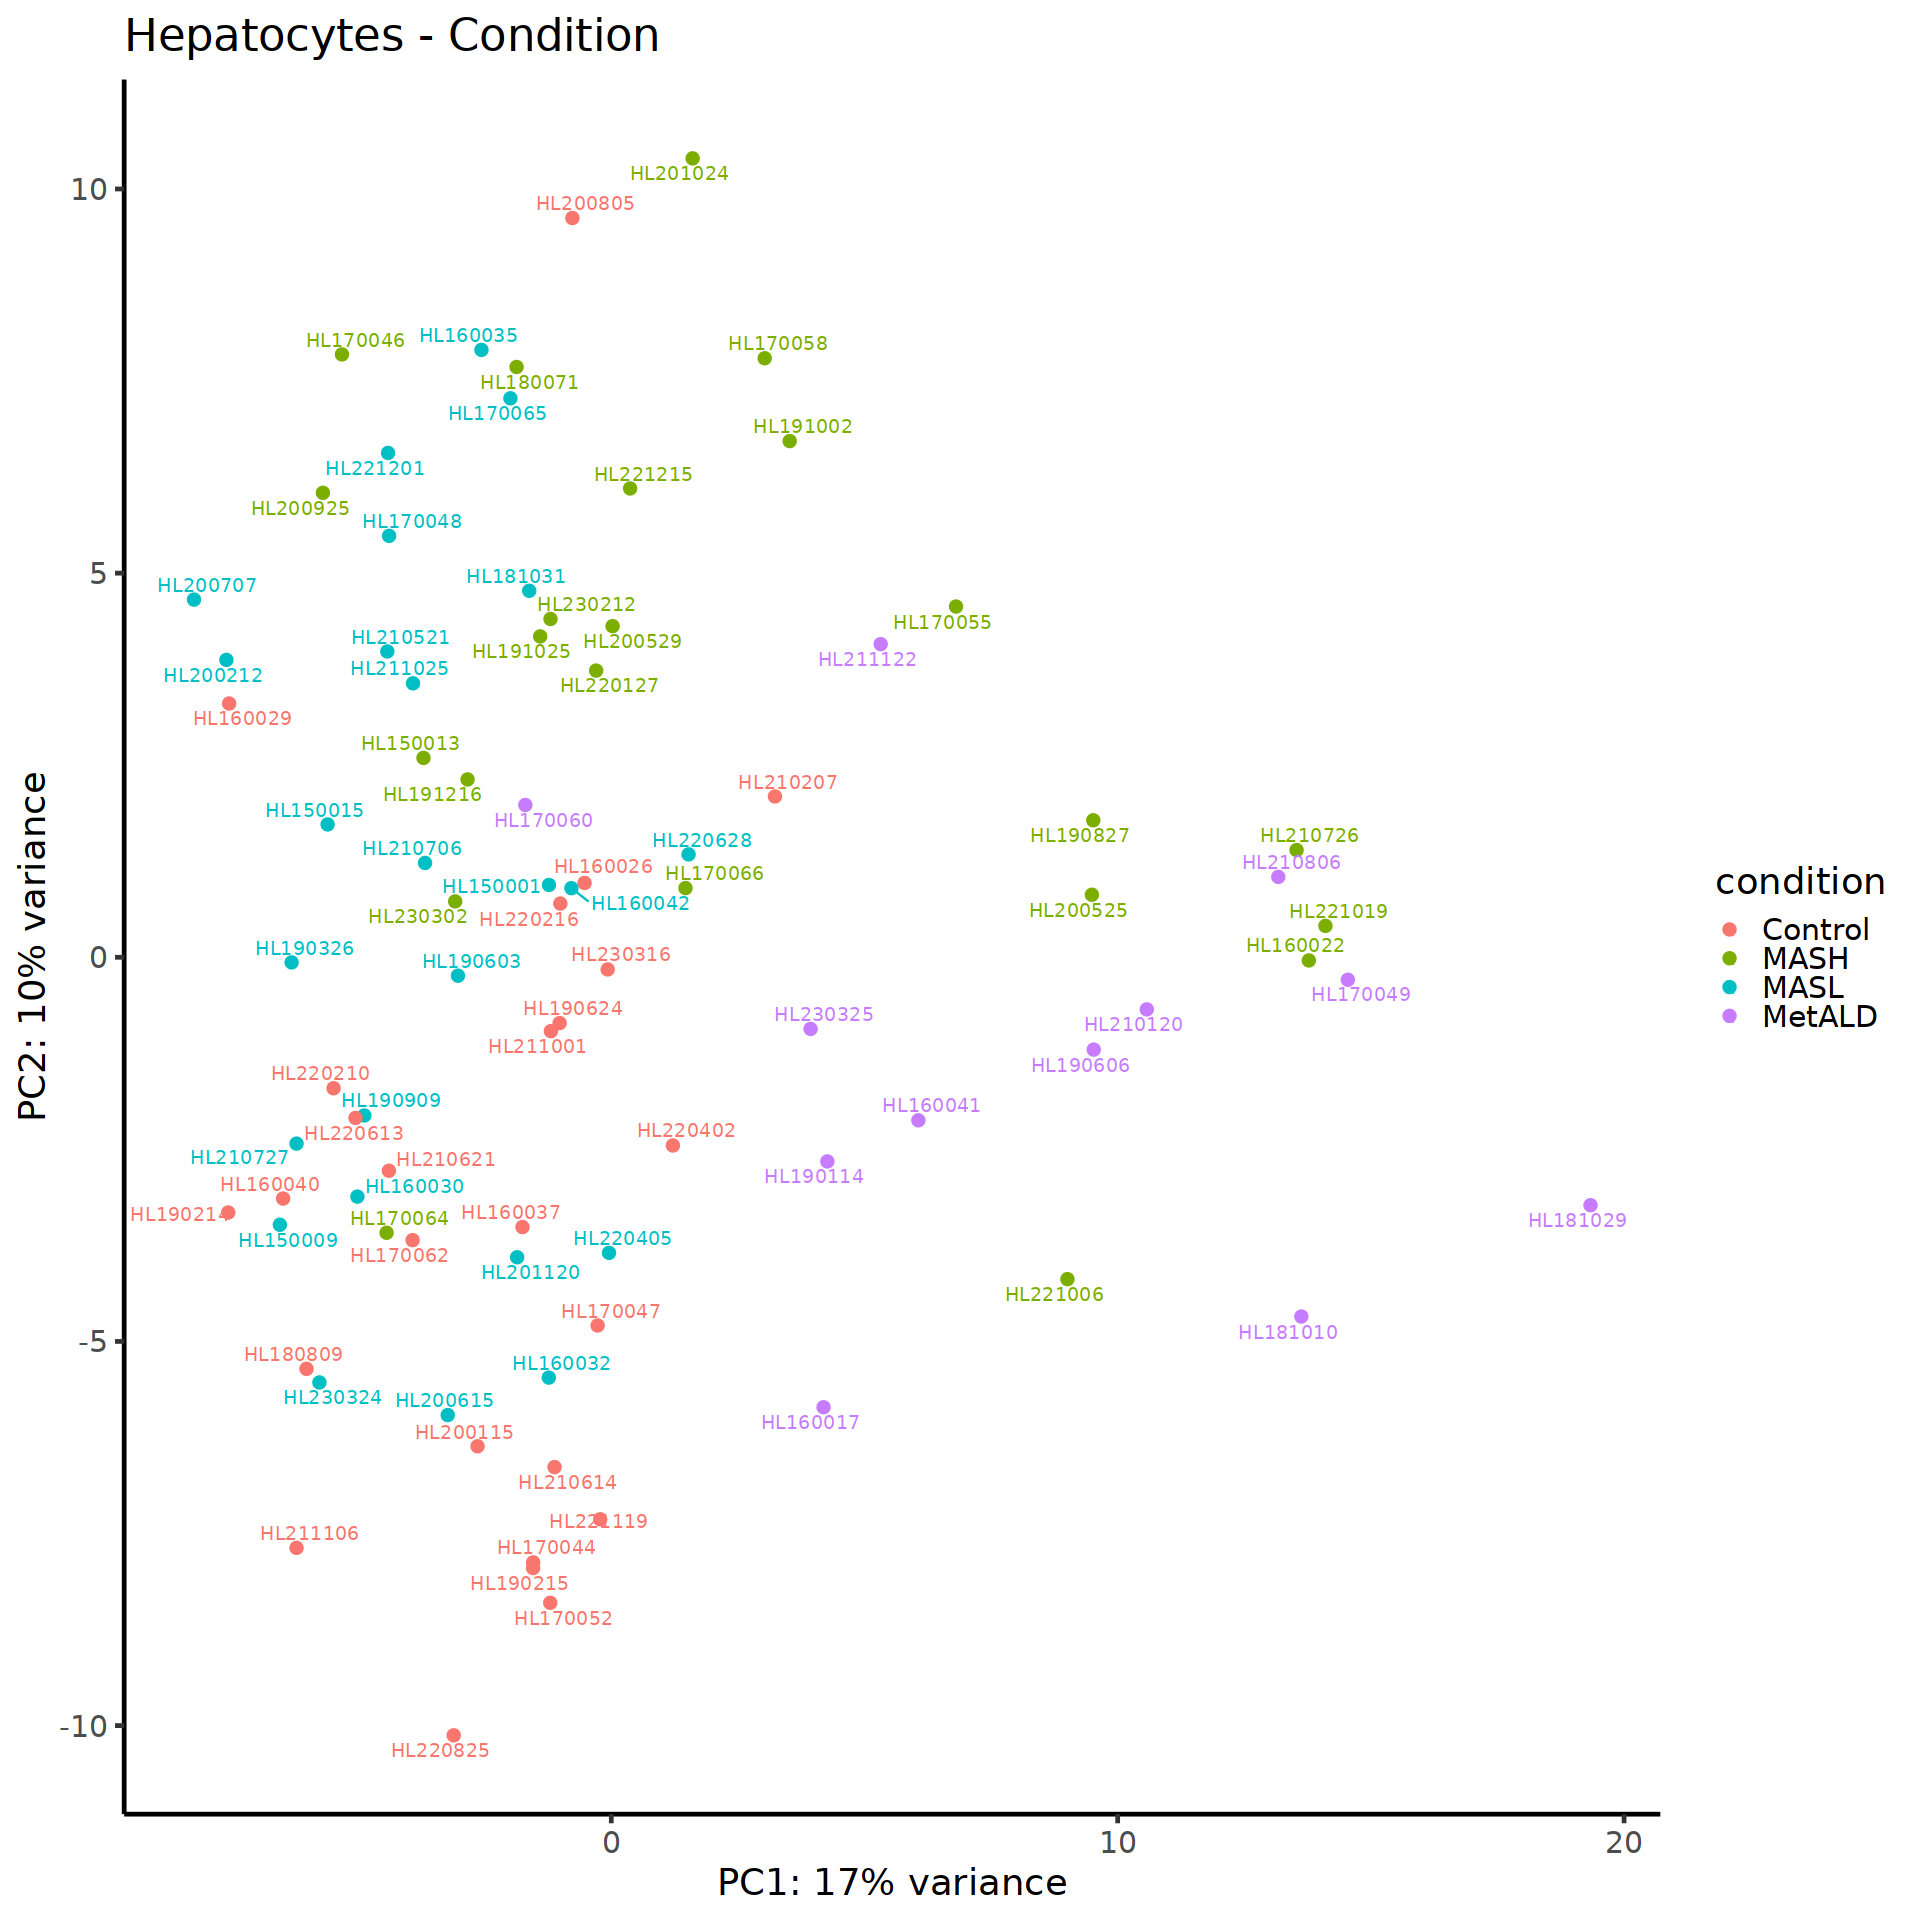

Warning message:
“ggrepel: 69 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Mast"
[1] 183028      0


Donors detectected with celltype: 0



[1] "Analyzing: Myeloid"
[1] 183028     86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance



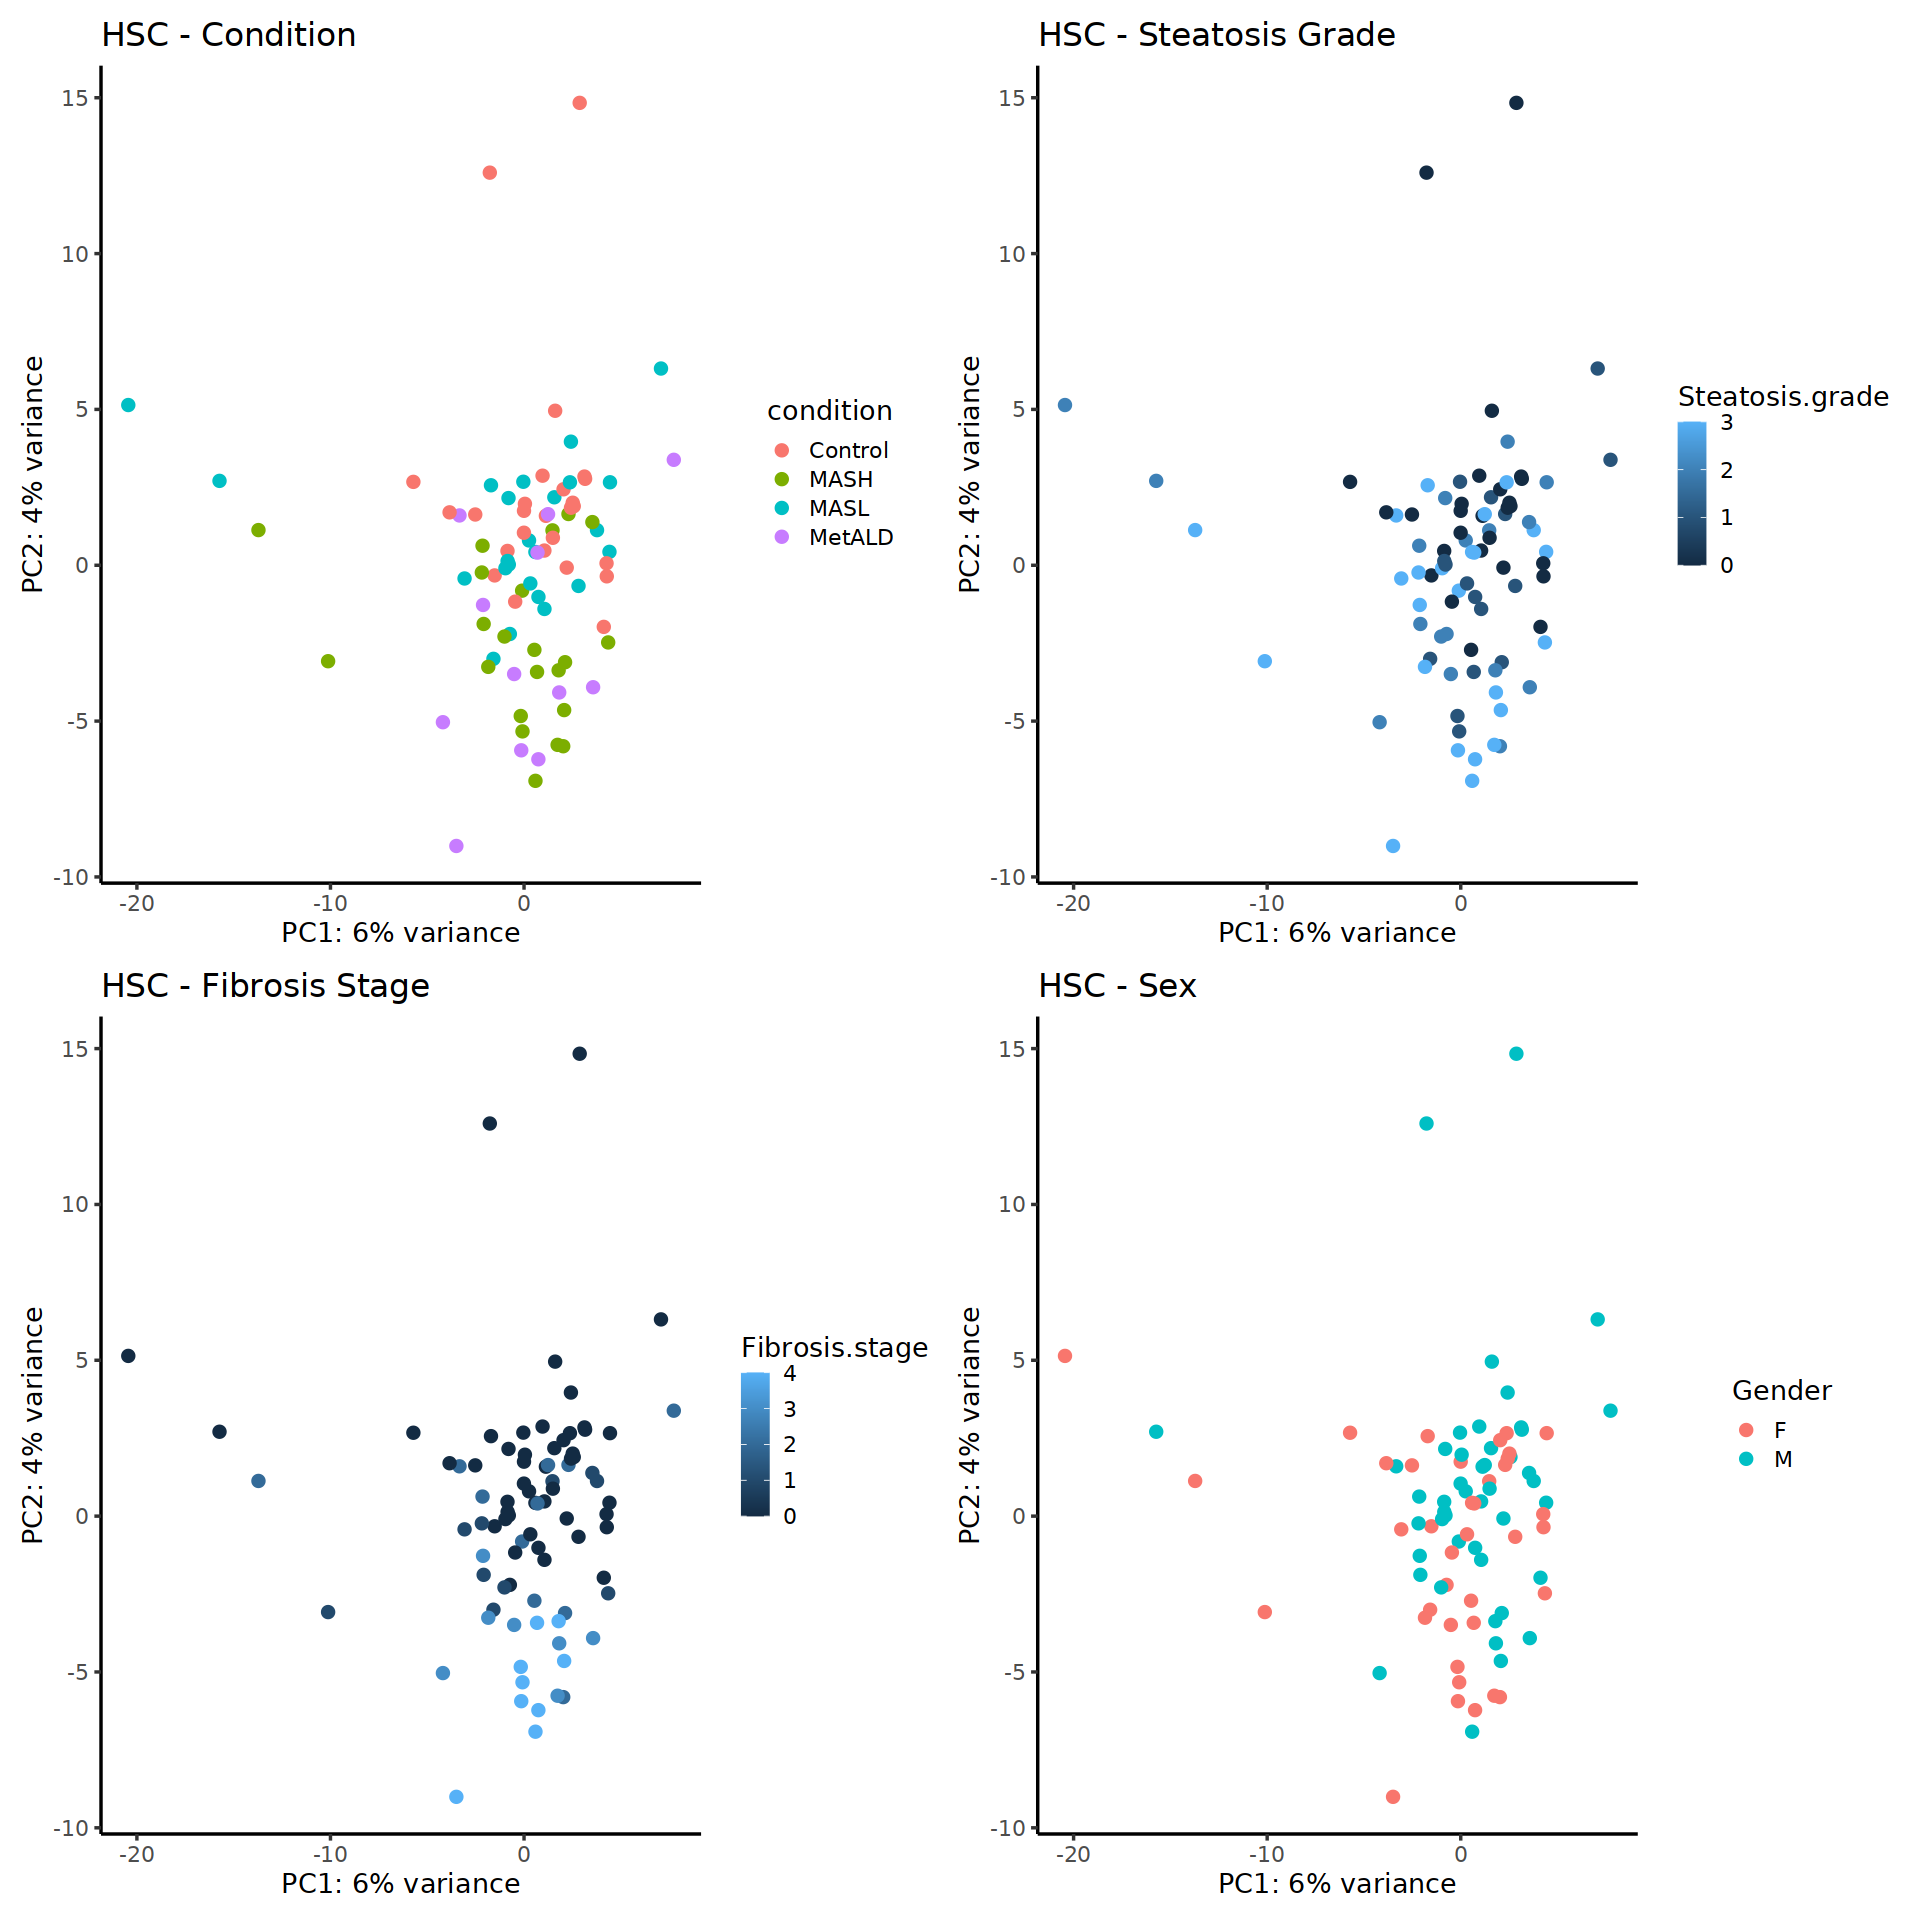

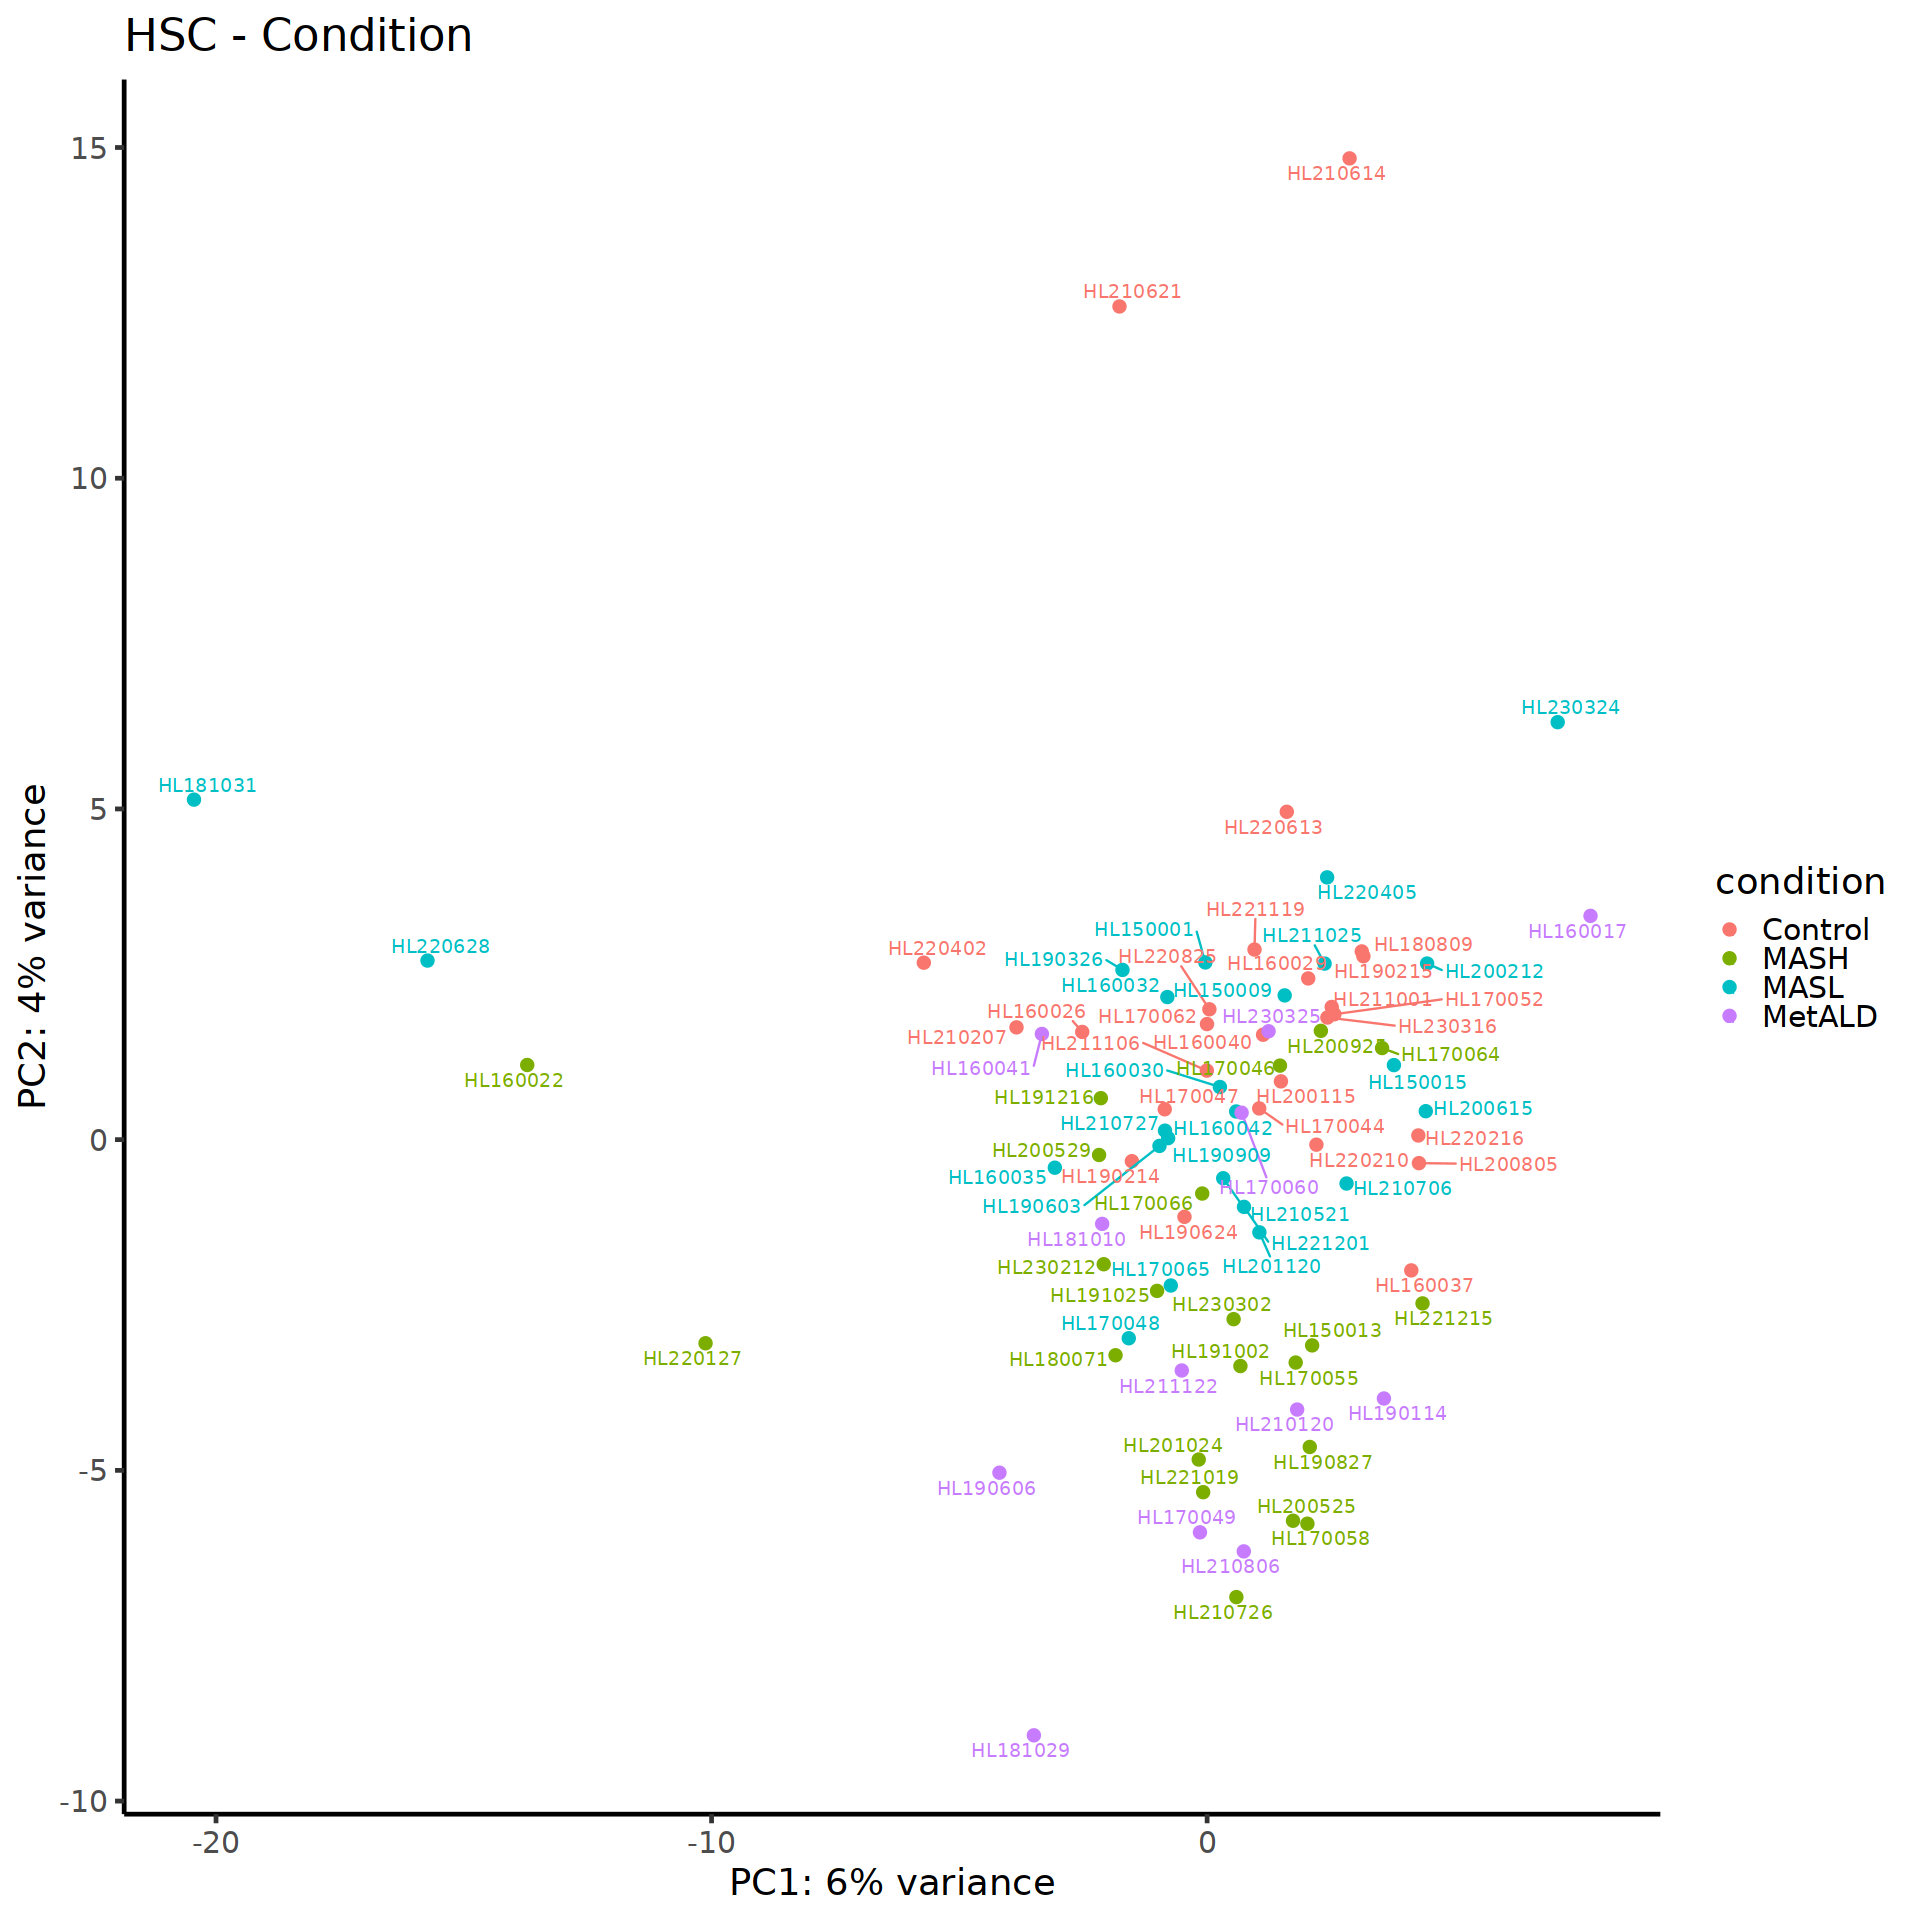

Warning message:
“ggrepel: 66 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: NK"
[1] 183028     56


Donors detectected with celltype: 56

subsetting metadata accordingly - Check that value is equal to above: 56

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


[1] "Analyzing: Schwann"
[1] 183028      0


Donors detectected with celltype: 0



[1] "Analyzing: T"
[1] 183028     68


Donors detectected with celltype: 68

subsetting metadata accordingly - Check that value is equal to above: 68

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


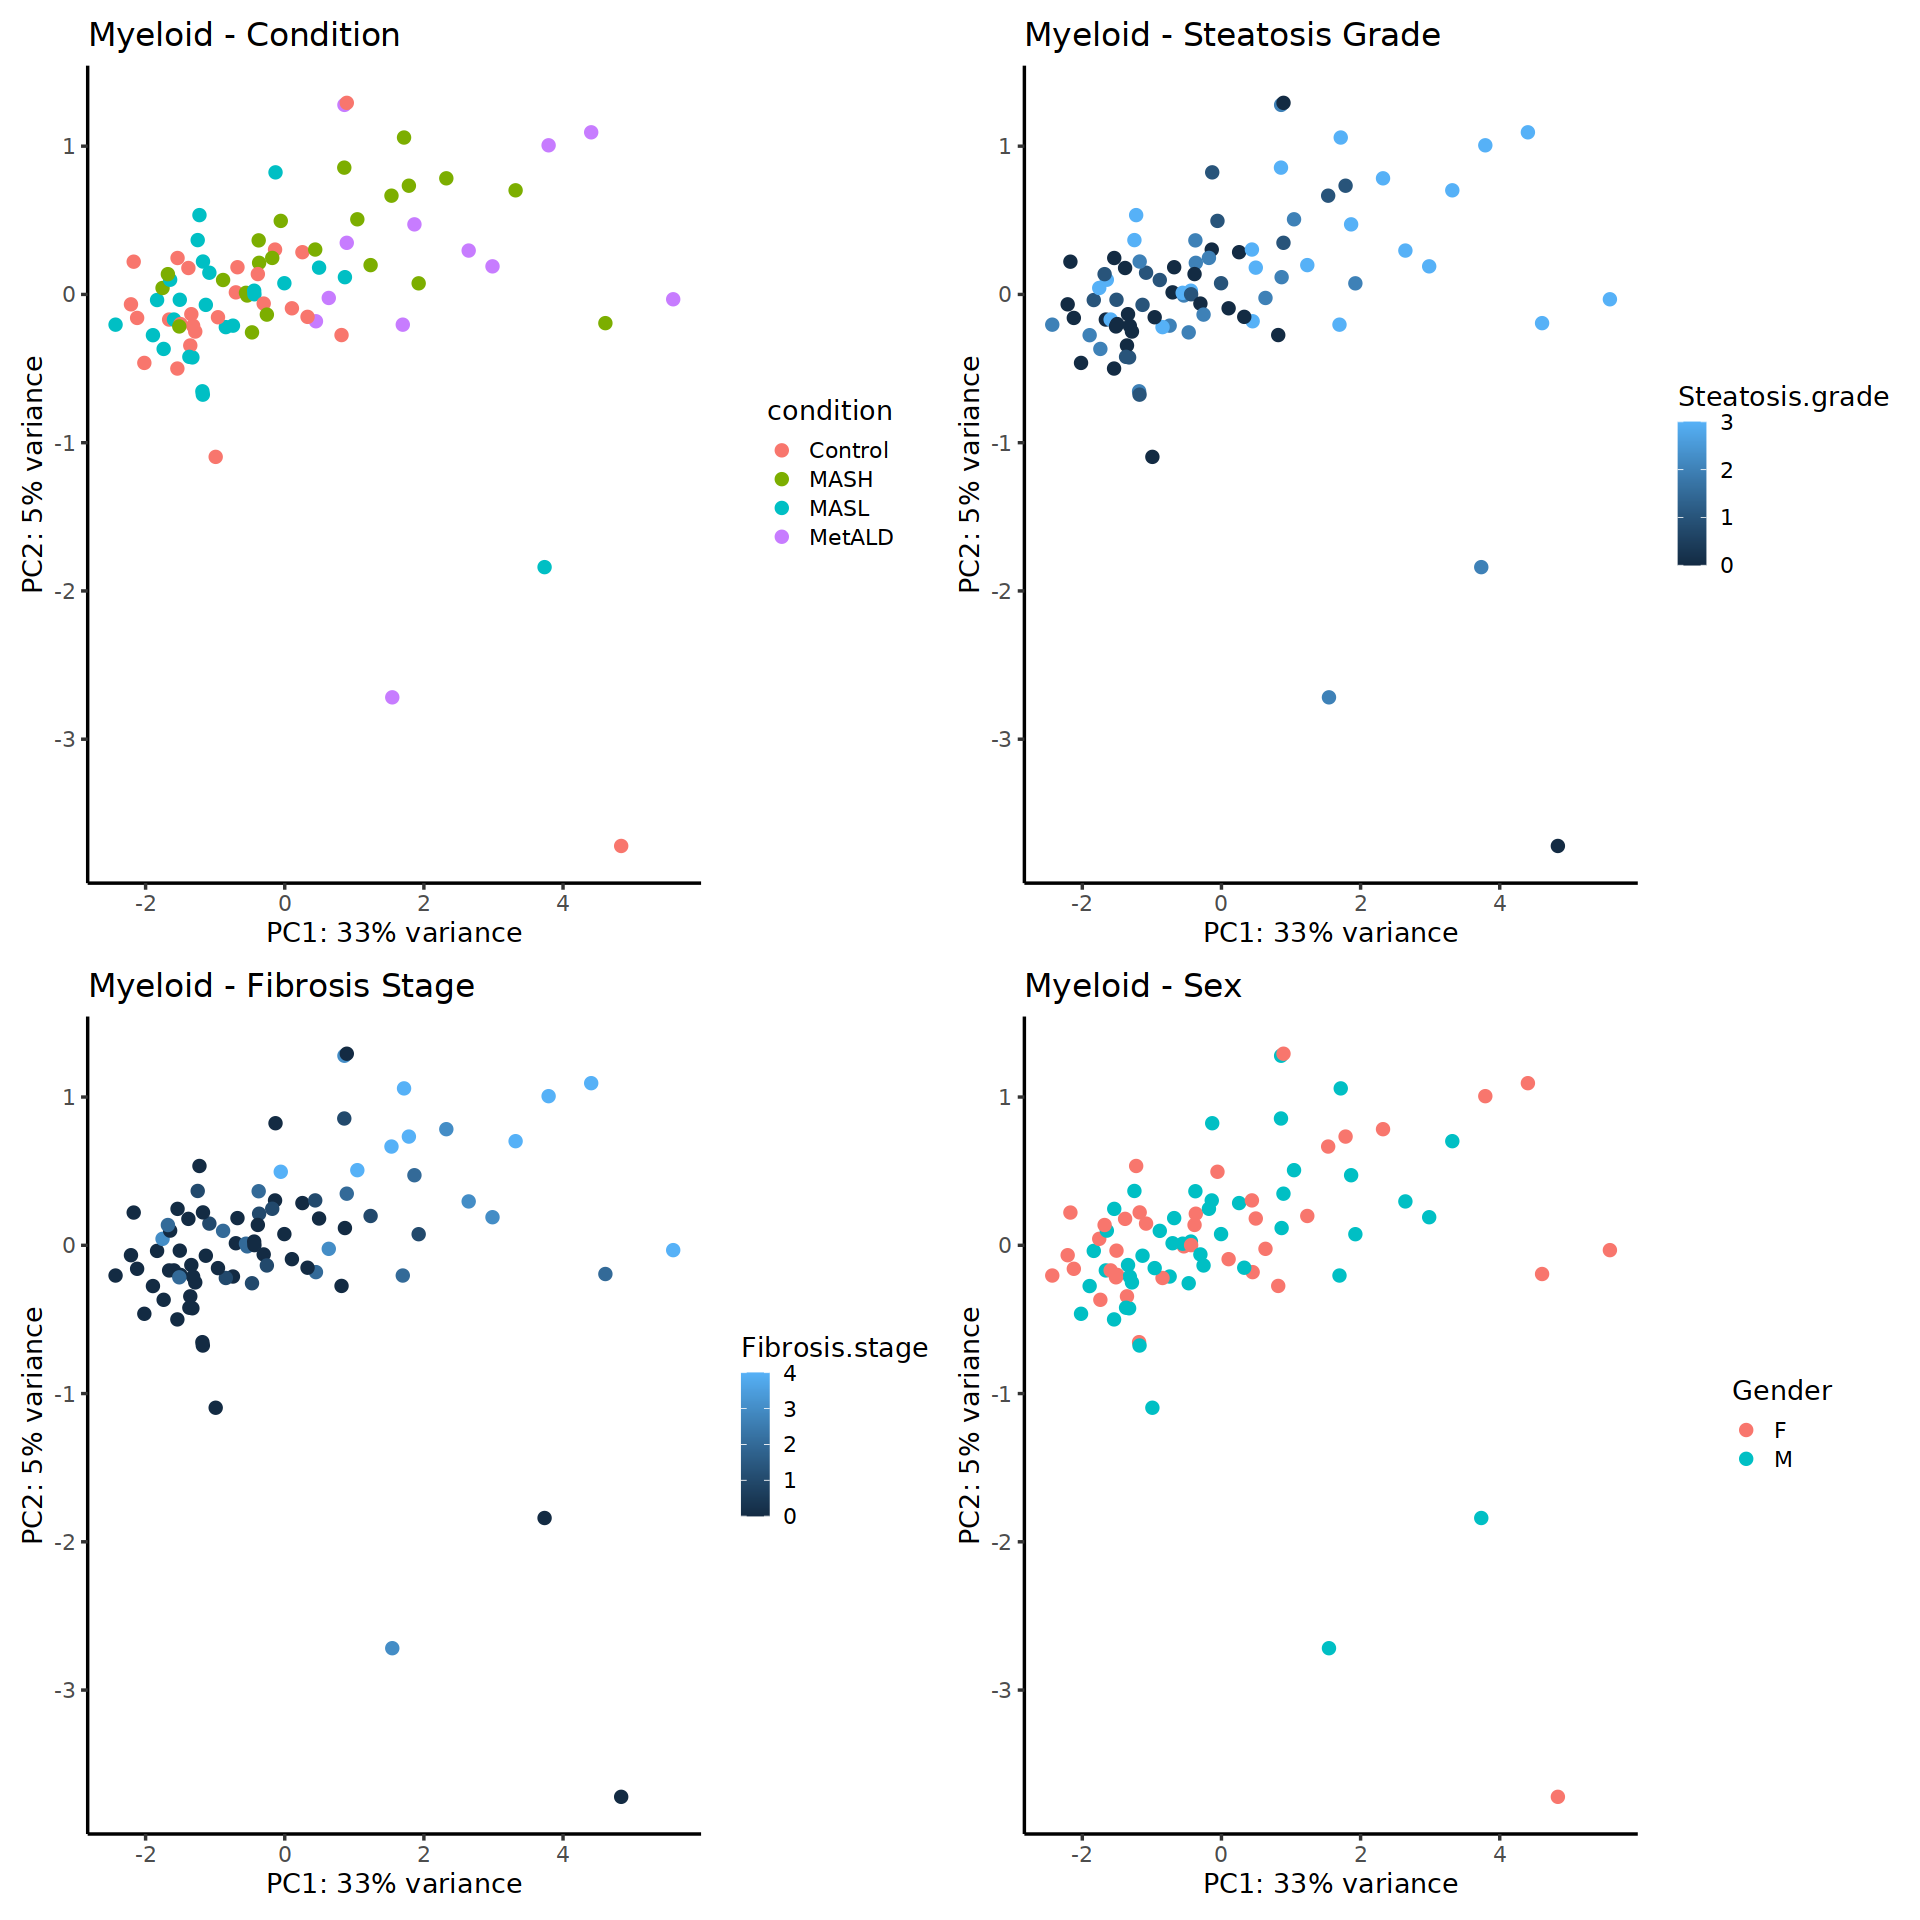

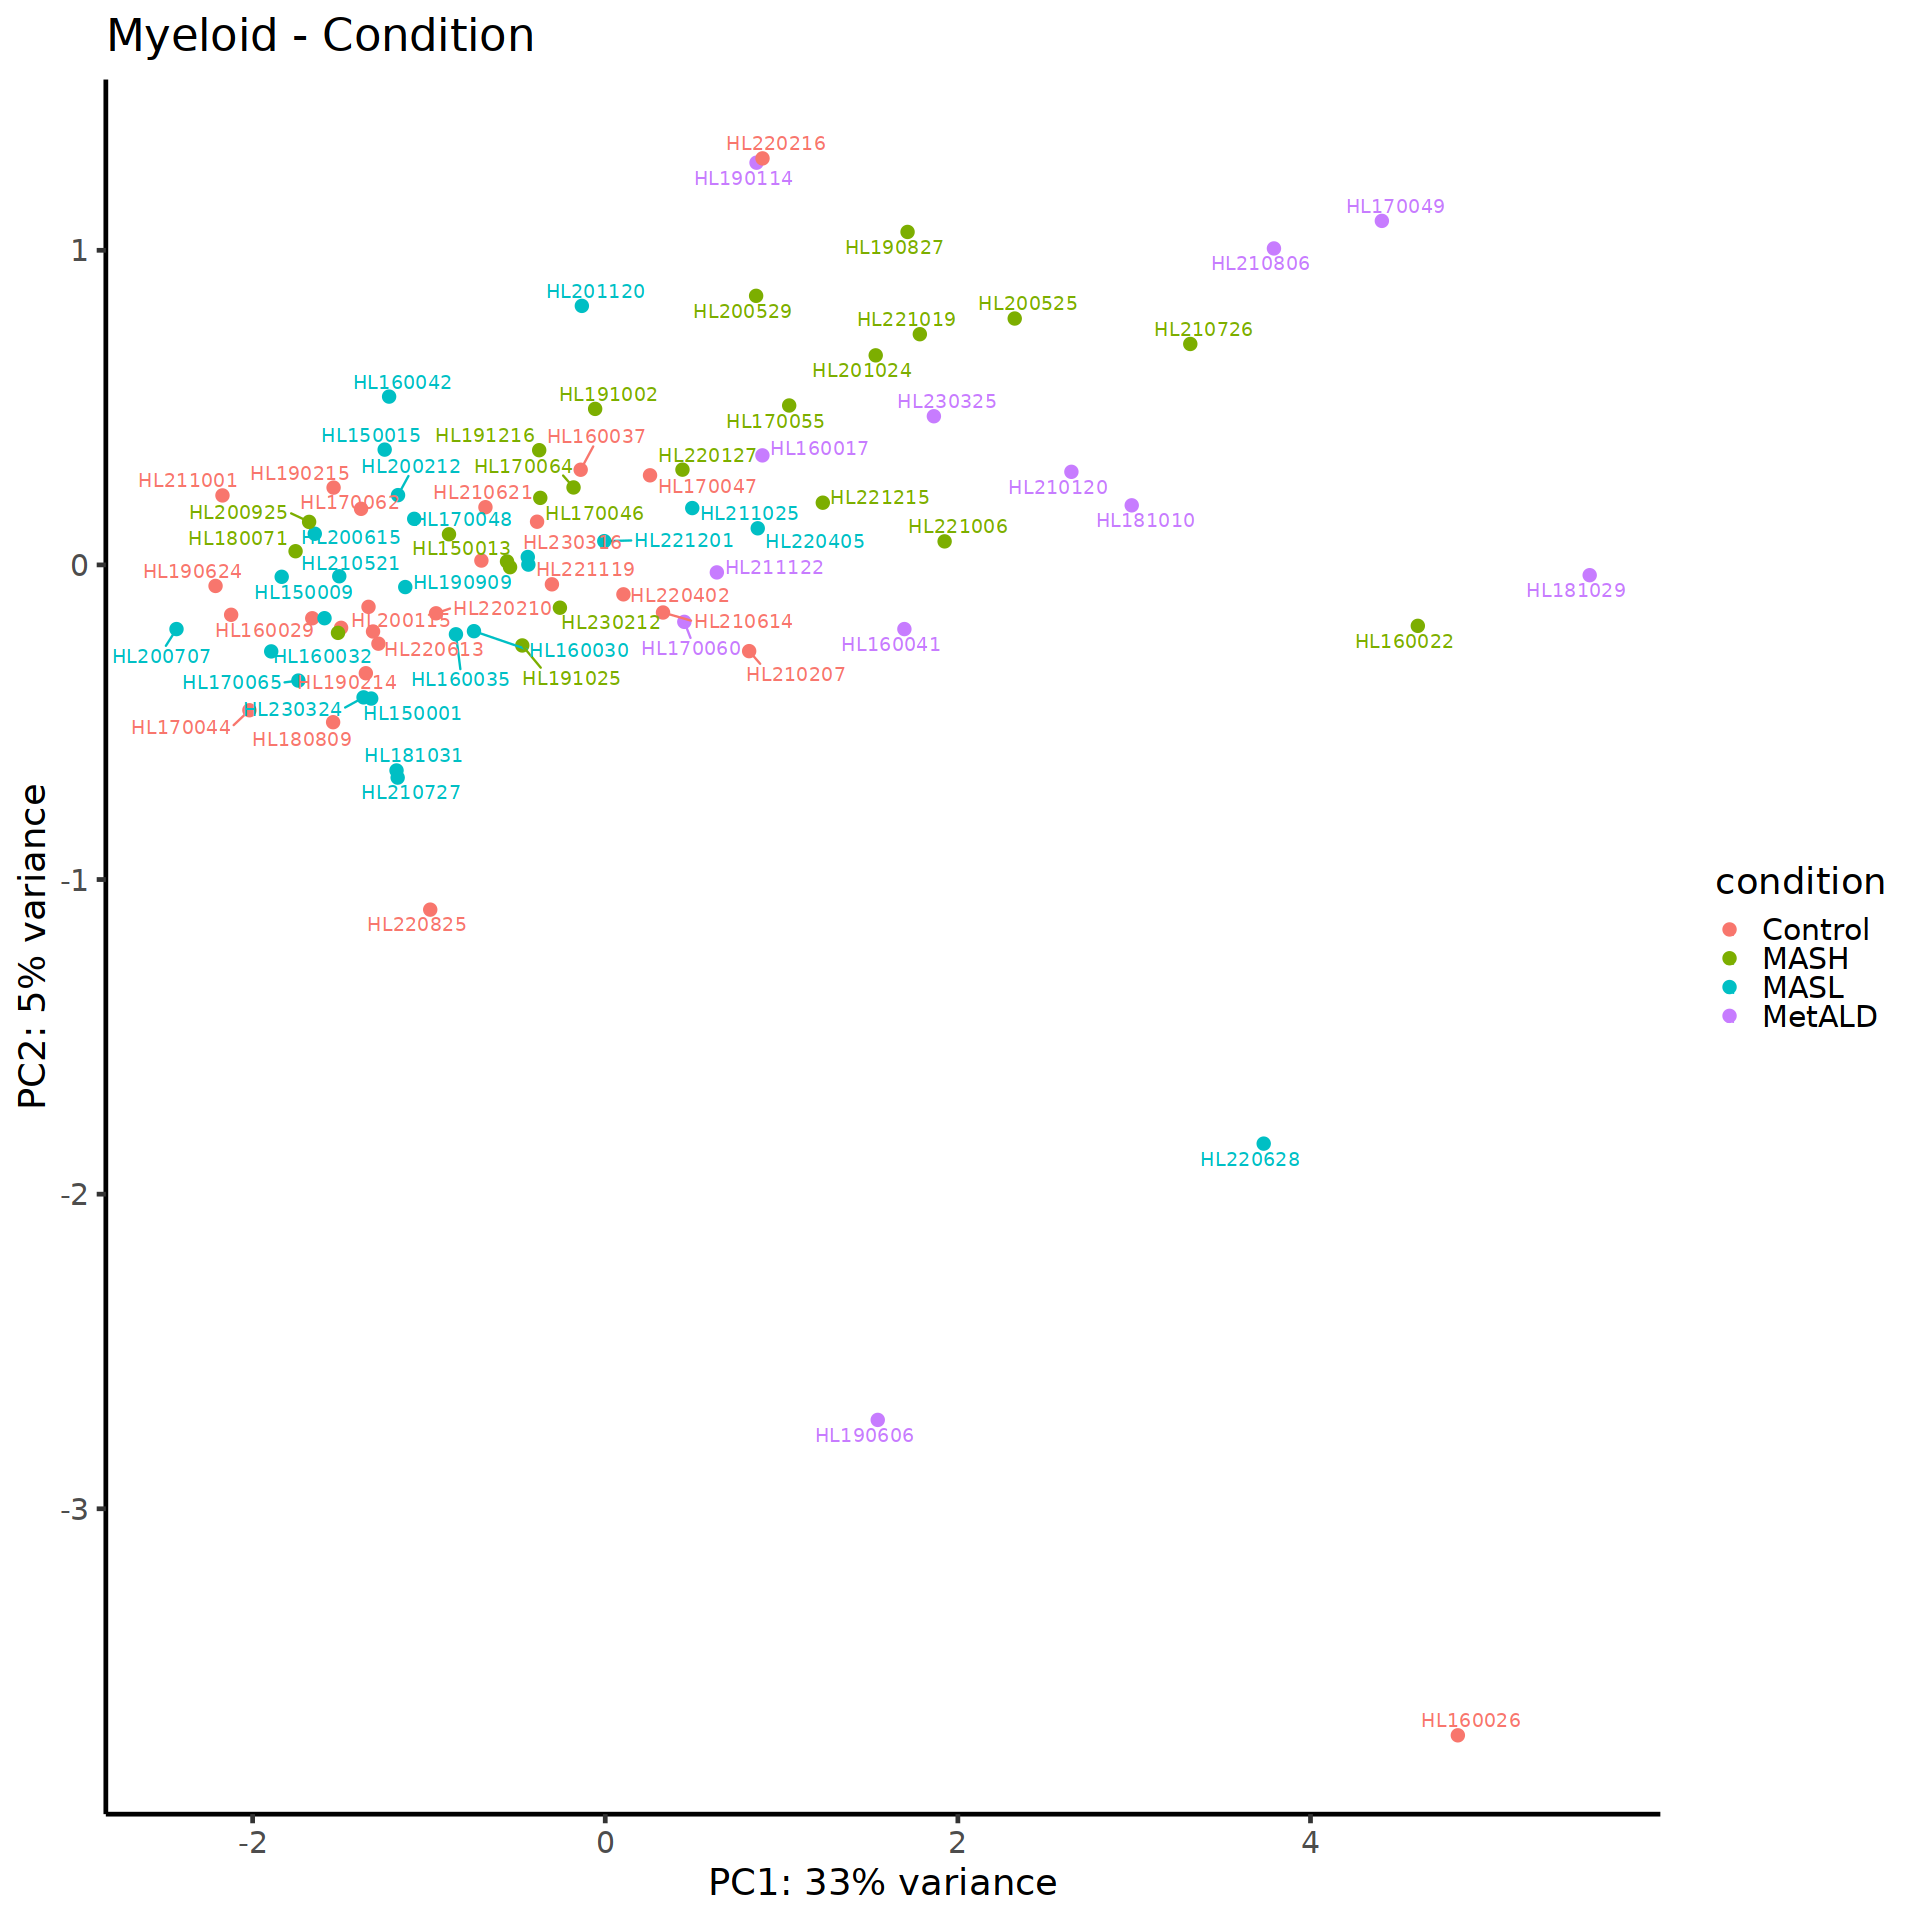

In [7]:
options(repr.plot.width=16, repr.plot.height=16)
pca_data <- list()

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '_'))
    # Remove low bc cells
    if (cell.use != 'Bulk') {
        raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    }
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    dds <- DESeqDataSetFromMatrix(countData = raw_counts,
                              colData = meta_cell,
                              design = ~ condition)
    dds <- estimateSizeFactors(dds)
    
    if (cell.use %in% c('B','NK','T')) next
    
    if (sum( rowMeans( counts(dds, normalized=TRUE)) > 5 ) < 1000) {
        vsd <- vst(dds, blind=FALSE, nsub = sum( rowMeans( counts(dds, normalized=TRUE)) > 5 ))
    } else {
        vsd <- vst(dds, blind=FALSE)
    }
    
    pcaData <- plotPCA(vsd, intgroup=c("condition"), returnData=TRUE)
    pca_data[[cell.use]] <- left_join(pcaData, select(meta_cell, -condition), join_by(name==donor_demux))
    gc()
    
    percentVar <- round(100 * attr(pca_data[[cell.use]], "percentVar"))

    p1 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=condition, label=name)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Condition')) + theme_classic(base_size=16)
        
    p2 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=Steatosis.grade)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Steatosis Grade')) + theme_classic(base_size=16)
        
    p3 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=Fibrosis.stage)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Fibrosis Stage')) + theme_classic(base_size=16)
        
    p4 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=Gender)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Sex')) + theme_classic(base_size=16)
    p6 <- p1 + p2 + p3 + p4
    print(p6)
    
    p5 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=condition, label=name)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Condition')) + theme_classic(base_size=22) + ggrepel::geom_text_repel(size=4)
    print(p5)
    
    write.table(pca_data[[cell.use]], paste0(outdir, cell.use, '_PCA.tsv'),
               sep='\t', col.names=T, row.names=T, quote=F)
}

# DESeq2 - Conditions status

In [18]:
meta = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/H3K27me3.meta.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
meta$Age.scaled = scale(meta$Age)
meta$BMI.scaled = scale(meta$BMI)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Fibrosis.stage,Fat.distribution,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>
1,HL150001,5,18,84,514,22,0,71,15,0,⋯,0,Centrizonal,0,0,0,0,1,M,47,27.1
2,HL150009,5,9,80,713,66,0,83,6,3,⋯,0,centrizonal,0,0,0,0,1,M,37,29.4


[1] "donor_demux"          "B"                    "Cholangiocyte"       
 [4] "Endothelial"          "Hepatocytes"          "HSC"                 
 [7] "Mast"                 "Myeloid"              "NK"                  
[10] "Schwann"              "T"                    "batch"               
[13] "disease_status"       "condition"            "Steatosis.grade"     
[16] "Fibrosis.stage"       "Fat.distribution"     "Lobular.inflammation"
[19] "Ballooning"           "Portal.inflammation"  "Hepatocyte.necrosis" 
[22] "MASH.CRN.score..X.8"  "Gender"               "Age"                 
[25] "BMI"                  "Age.scaled"           "BMI.scaled"

In [9]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/bins_mtx/'
#Create outdir for results
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/'
dir.create(outdir)
# dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_H3K27me3_donor.15kb_bin.rpm.xls')
#Cut off file suffices to get celltype names
cells <- gsub('_H3K27me3_donor.15kb_bin.rpm.xls','', files)

files
cells

Warning message in dir.create(outdir):
“'/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins' already exists”


[1] "B_H3K27me3_donor.15kb_bin.rpm.xls"            
 [2] "Cholangiocyte_H3K27me3_donor.15kb_bin.rpm.xls"
 [3] "Endothelial_H3K27me3_donor.15kb_bin.rpm.xls"  
 [4] "Hepatocytes_H3K27me3_donor.15kb_bin.rpm.xls"  
 [5] "HSC_H3K27me3_donor.15kb_bin.rpm.xls"          
 [6] "Mast_H3K27me3_donor.15kb_bin.rpm.xls"         
 [7] "Myeloid_H3K27me3_donor.15kb_bin.rpm.xls"      
 [8] "NK_H3K27me3_donor.15kb_bin.rpm.xls"           
 [9] "Schwann_H3K27me3_donor.15kb_bin.rpm.xls"      
[10] "T_H3K27me3_donor.15kb_bin.rpm.xls"

[1] "B"             "Cholangiocyte" "Endothelial"   "Hepatocytes"  
 [5] "HSC"           "Mast"          "Myeloid"       "NK"           
 [9] "Schwann"       "T"

In [10]:
# List your contrasts  
conditions.1 = c("MASL", "MASH", "MetALD") # disease
conditions.2 = c("Control", "Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [11]:
unique(meta$condition)

[1] "MASL"    "MASH"    "MetALD"  "Control"

In [12]:
seq_along(files)

[1]  1  2  3  4  5  6  7  8  9 10

In [19]:
deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.1) %>% 
                               pull(donor)
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            if (is.null(nrow(raw_counts_subset))) {
                next
            }
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            if (nrow(counts_filtered) < 3) {
                next
            }
            
            # Run DESeq2
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                          colData = meta_cell.use, 
                                          design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
            
            # Write DESeq results to file
            write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
            
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: B"
[1] 183028     37


Donors detectected with celltype: 37

subsetting metadata accordingly - Check that value is equal to above: 37

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Cholangiocyte"
[1] 183028     83


Donors detectected with celltype: 83

subsetting metadata accordingly - Check that value is equal to above: 83

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Endothelial"
[1] 183028     86


...

Donors detectected with celltype: 56

subsetting metadata accordingly - Check that value is equal to above: 56

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Schwann"
[1] 183028      0


Donors detectected with celltype: 0



[1] "Analyzing: T"
[1] 183028     68


Donors detectected with celltype: 68

subsetting metadata accordingly - Check that value is equal to above: 68

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


In [20]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,3118,1043,3,37
B,MASH_vs_Control,7523,931,94,1
B,MetALD_vs_Control,3585,1144,173,134
Cholangiocyte,MASL_vs_Control,1836,3229,0,1
Cholangiocyte,MASH_vs_Control,2860,3020,15,45
Cholangiocyte,MetALD_vs_Control,2733,5530,143,759
Endothelial,MASL_vs_Control,3733,2688,0,0
Endothelial,MASH_vs_Control,5797,2650,51,16
Endothelial,MetALD_vs_Control,6308,5544,61,181


In [21]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control
<chr>,<int>,<int>,<int>
B,40,95,307
Cholangiocyte,1,60,902
Endothelial,0,67,242
Hepatocytes,32,1373,6825
HSC,4,73,86
Myeloid,2,464,23747
NK,22,72,1678
T,9,1,662


In [22]:
deseq.stats2 <- deseq.stats

In [23]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


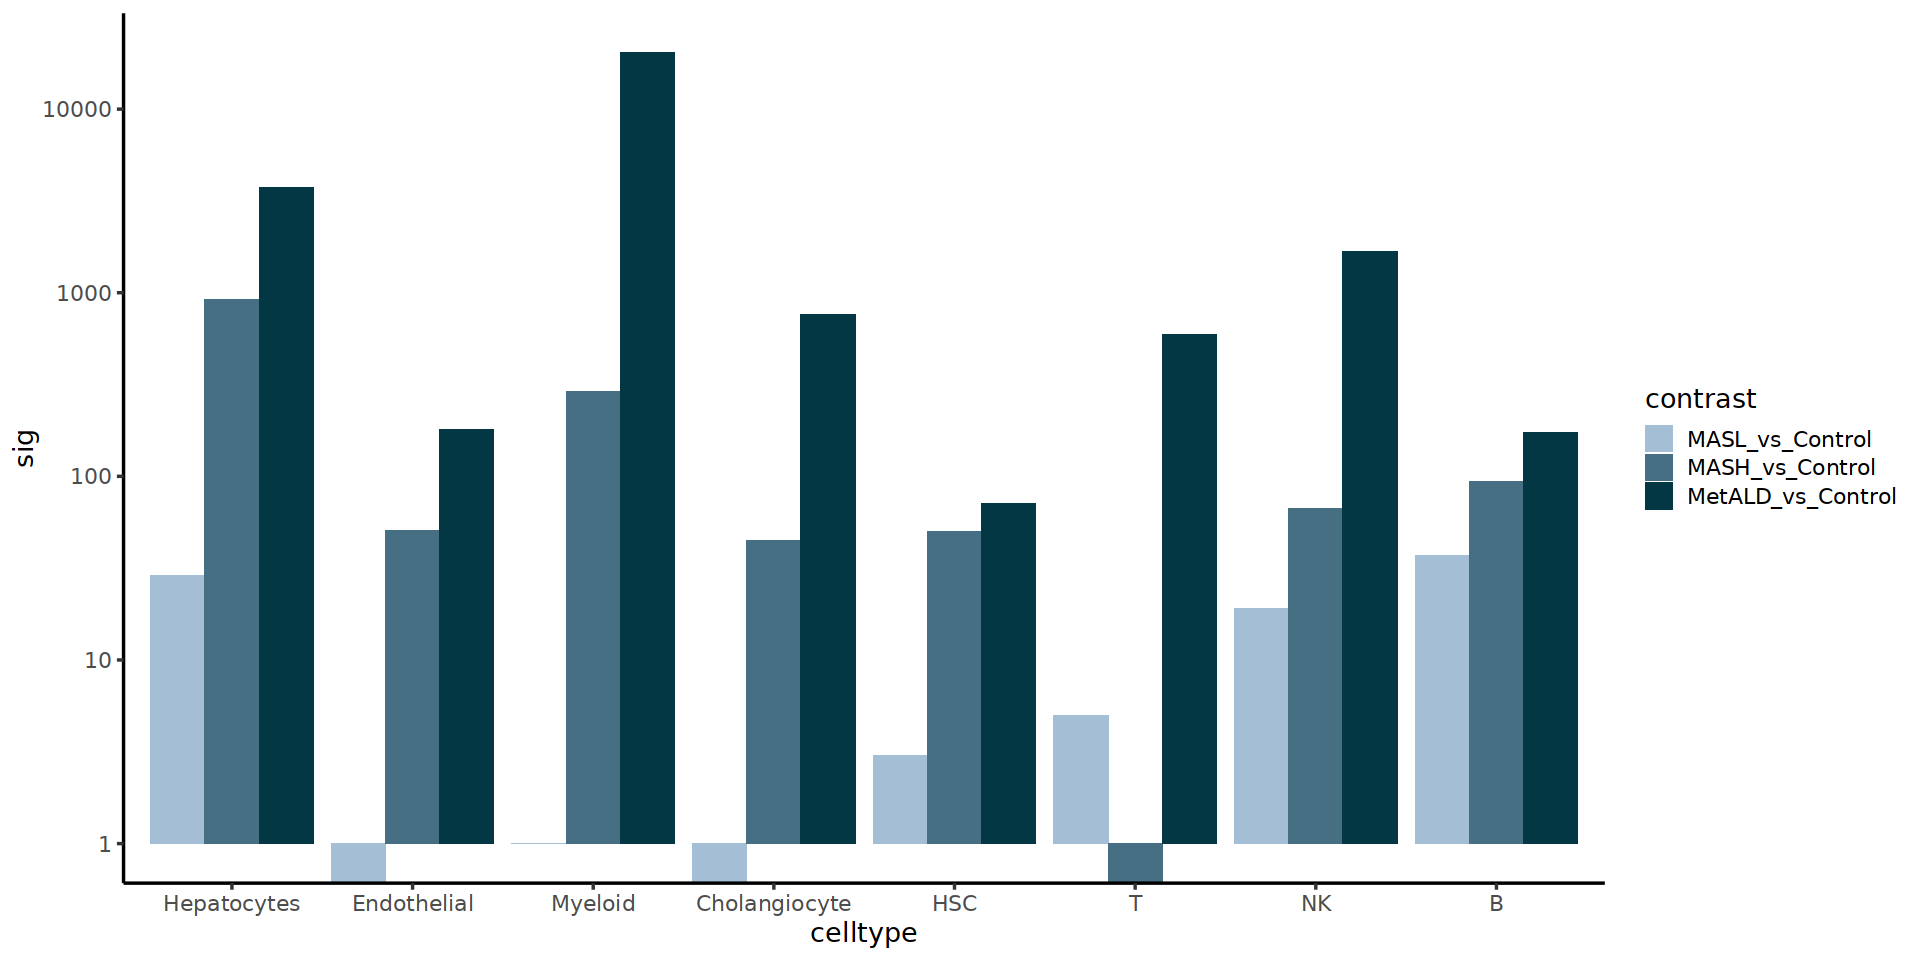

In [25]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
scale_y_log10()+
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### MASH_ALL

In [ ]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    contrast.use <- 'MASH_ALL_vs_Control'
    
    condition.1 = c('MASH','MetALD')
    condition.2 = 'Control'
    message(" - ", contrast.use)

    # Create vectors of samples for each condition
    samples.condition.1 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.1) %>% 
                           pull(donor)
    samples.condition.2 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.2) %>% 
                           pull(donor)
    
    if(length(samples.condition.1) < 3) {
        next
    }
    if(length(samples.condition.2) < 3) {
        next
    }
    
    # Subset meta_cell for the current contrast
    meta_cell.use <- meta_cell %>% 
                 dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
    meta_cell.use[meta_cell.use$condition == 'MASH',]$condition <- 'MASH_ALL'
    meta_cell.use[meta_cell.use$condition == 'MetALD',]$condition <- 'MASH_ALL'
    rownames(meta_cell.use) <- meta_cell.use$donor
    
    # Subset raw_counts for the donors in meta_cell
    raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
    
    # Check if enough samples are present for both conditions
    if (length(unique(meta_cell$condition)) >= 2) {
        deseq.stats.tmp <- data.frame()
        
        if (is.null(nrow(raw_counts_subset))) {
                next
        }
        
        # Light pre-filtering
        counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
        counts_filtered <- counts_filtered[,colSums(counts_filtered) > 0]
        
        if (nrow(counts_filtered) < 3) {
            next
        }

        # Run DESeq2
        dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                      colData = meta_cell.use, 
                                      design = deseq.formula)
        dds$condition <- relevel(dds$condition, ref = condition.2)
        dds <- DESeq(dds)
        dds.results <- results(dds)
        
        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
        
        dds.results <- na.omit(dds.results[order(dds.results$padj), ])

        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
        
        # Collect summary statistics
        deseq.stats.tmp <- data.frame(
            celltype = cell.use,
            contrast = contrast.use,
            up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
            down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
            up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
            down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
            deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                       # Make Volcano plot - Padj
                        res = as.data.frame(dds.results)
                        res$SYMBOL = rownames(res)
                        res = res %>%
                        dplyr::filter(!is.na(SYMBOL)) %>%
                        dplyr::filter(padj < 0.1) %>%
                        dplyr::group_by(sign(log2FoldChange)) %>%
                        dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                        dplyr::top_n(50, rank) %>%
                        dplyr::mutate(delabel = SYMBOL) %>%
                        ungroup() %>%
                        dplyr::select(delabel, SYMBOL) %>%
                        right_join(res) %>%
                        dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                        # Add a new column for color based on significance and direction
                        res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                            ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                        # Get the number of upregulated and downregulated genes
                        n_up <- sum(res$changes == "Up-regulated")
                        n_down <- sum(res$changes == "Down-regulated")

                        # Modify log2FoldChange values to be max x
                        res$log2FoldChange[res$log2FoldChange > 10] <- 10
                        res$log2FoldChange[res$log2FoldChange < -10] <- -10
                        # Modify padj values to be max x 
                        res$padj[res$padj < 10^-200] <- 10^-200
                
                        plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                            theme_bw() +
                            labs(y="-log10(padj)", x="log2FoldChange", 
                               title=paste(cell.use, " - ",
                                           condition.1, "Vs", condition.2, "\n",
                                          "Up: ", n_up, "-",
                                           "Down: ", n_down)) +
                            geom_point() +
                            scale_color_manual(values=c("blue", "grey", "red")) + 
                            theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                            scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                        labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                            scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                        labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                            geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                          point.padding=0, min.segment.length=0,
                                          max.time=20, max.iter=1e5, box.padding=0.3)
                
                        ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                               height = 10, width = 10,
                               plot = plot, device = "pdf")
    } else {
        message("Not enough samples for contrast: ", contrast.use)
    }
}

[1] "Analyzing: B"
[1] 183028     37


Donors detectected with celltype: 37

subsetting metadata accordingly - Check that value is equal to above: 37

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Cholangiocyte"
[1] 183028     83


Donors detectected with celltype: 83

subsetting metadata accordingly - Check that value is equal to above: 83

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Endothelial"
[1] 183028     86


...

Donors detectected with celltype: 56

subsetting metadata accordingly - Check that value is equal to above: 56

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Schwann"
[1] 183028      0


Donors detectected with celltype: 0



[1] "Analyzing: T"
[1] 183028     68


Donors detectected with celltype: 68

subsetting metadata accordingly - Check that value is equal to above: 68

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

In [67]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,3118,1043,3,37
B,MASH_vs_Control,7523,931,94,1
B,MetALD_vs_Control,3585,1144,173,134
Cholangiocyte,MASL_vs_Control,1836,3229,0,1
Cholangiocyte,MASH_vs_Control,2860,3020,15,45
Cholangiocyte,MetALD_vs_Control,2733,5530,143,759
Endothelial,MASL_vs_Control,3733,2688,0,0
Endothelial,MASH_vs_Control,5797,2650,51,16
Endothelial,MetALD_vs_Control,6308,5544,61,181


In [ ]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

In [ ]:
deseq.stats2 <- deseq.stats

In [ ]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control"))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

In [ ]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### Fibrosis

In [ ]:
contrasts  <- c('Fibrosis.stage')


# Define the DESeq2 formula
deseq.base.formula <- '~ Age.scaled + BMI.scaled + batch + Gender'

In [33]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            if (is.null(nrow(raw_counts_subset))) {
                next
            }
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
            
            if (nrow(counts_filtered) < 3) {
                next
            }

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
Warning message:
“ggrepel: 52 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Cholangiocyte"
[1] 183028     83


Donors detectected with celltype: 83

Subsetting metadata accordingly - Check that value is equal to above: 83

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Endothelial"
[1] 183028     86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



...

Donors detectected with celltype: 56

Subsetting metadata accordingly - Check that value is equal to above: 56

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Schwann"
[1] 183028      0


Donors detectected with celltype: 0



[1] "Analyzing: T"
[1] 183028     68


Donors detectected with celltype: 68

Subsetting metadata accordingly - Check that value is equal to above: 68

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



In [34]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,3118,1043,3,37
B,MASH_vs_Control,7523,931,94,1
B,MetALD_vs_Control,3585,1144,173,134
Cholangiocyte,MASL_vs_Control,1836,3229,0,1
Cholangiocyte,MASH_vs_Control,2860,3020,15,45
Cholangiocyte,MetALD_vs_Control,2733,5530,143,759
Endothelial,MASL_vs_Control,3733,2688,0,0
Endothelial,MASH_vs_Control,5797,2650,51,16
Endothelial,MetALD_vs_Control,6308,5544,61,181


In [35]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage
<chr>,<int>,<int>,<int>,<int>,<int>
B,40,95,307,175,151
Cholangiocyte,1,60,902,752,2760
Endothelial,0,67,242,239,1955
Hepatocytes,32,1373,6825,8465,51656
HSC,4,73,86,243,742
Myeloid,2,464,23747,15043,39880
NK,22,72,1678,21,74
T,9,1,662,9,39


In [36]:
deseq.stats2 <- deseq.stats

In [37]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

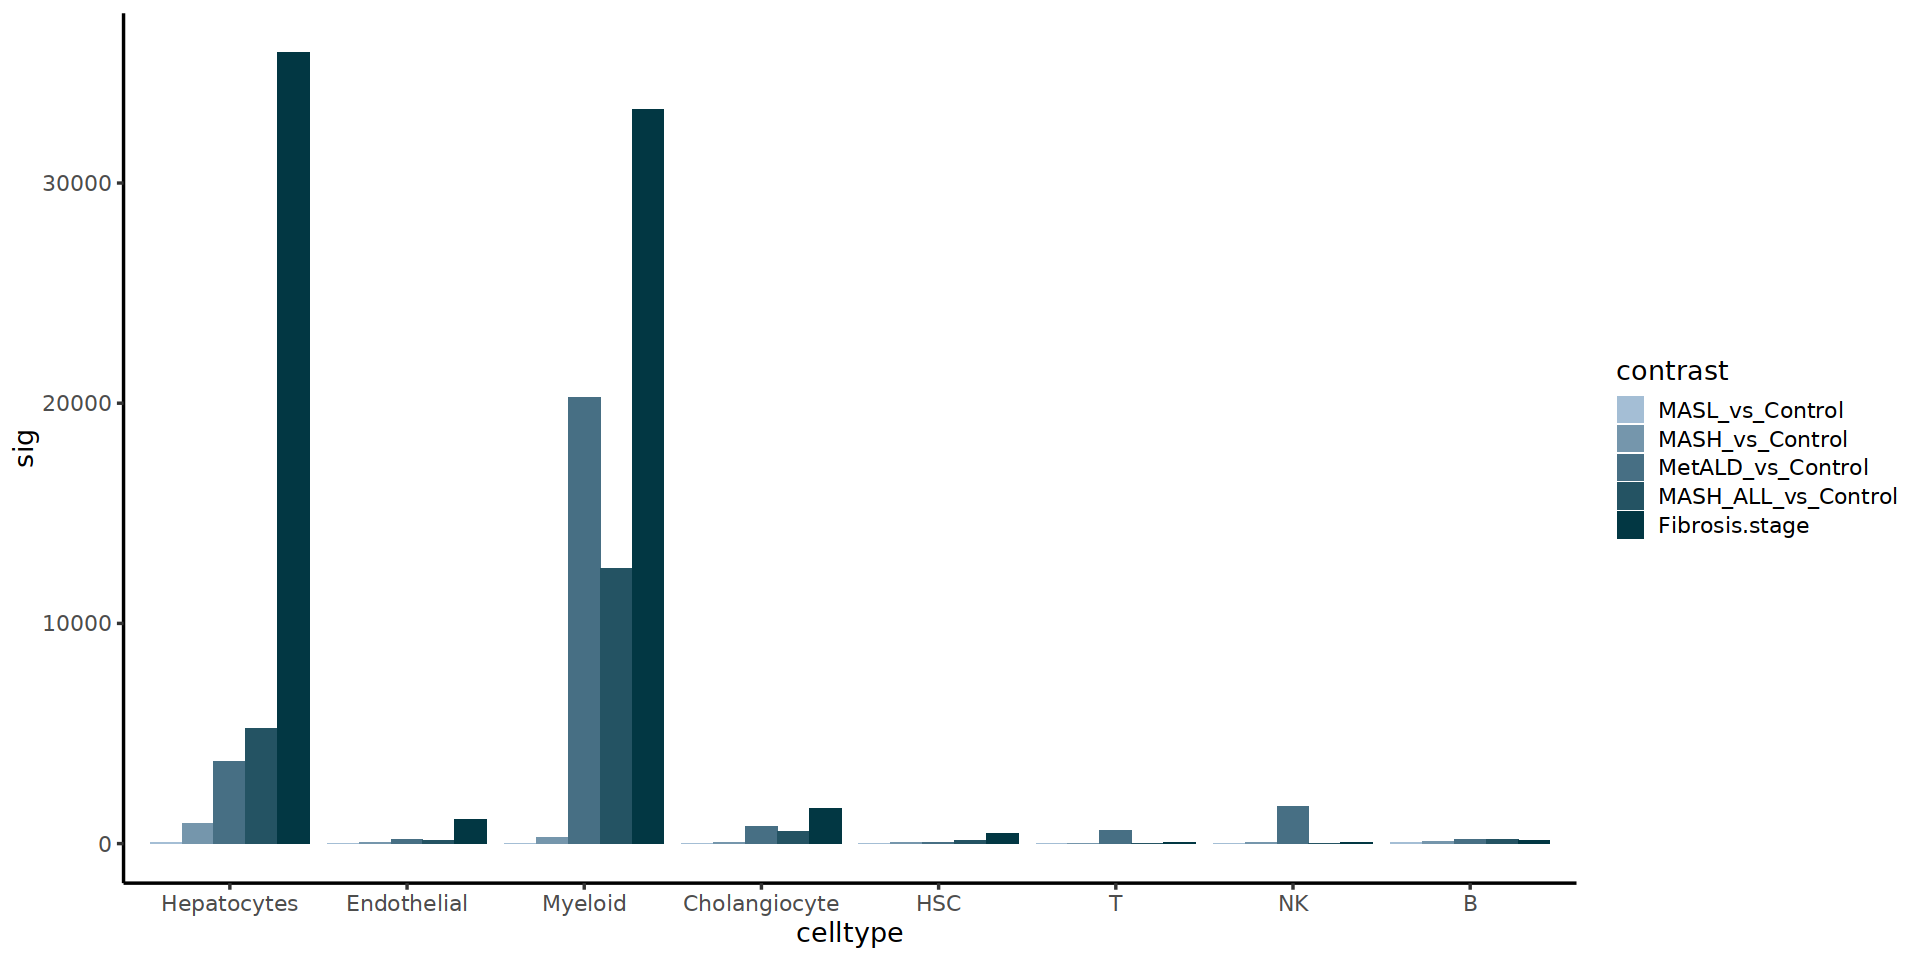

In [38]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [39]:
write.table(deseq.stats, paste0(outdir, '241024_WE_deseq_summary.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

### Other Meta

In [40]:
contrasts  <- c('Steatosis.grade', 'Lobular.inflammation', 'Ballooning', 'MASH.CRN.score..X.8')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + BMI.scaled + batch + Gender'

In [41]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            if (is.null(nrow(raw_counts_subset))) {
                next
            }
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
            
            if (nrow(counts_filtered) < 3) {
                next
            }

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: B"
[1] 183028     37


Donors detectected with celltype: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Cholangiocyte"
[1] 183028     83


Donors detectected with celltype: 83

Subsetting metadata accordingly - Check that value is equal to above: 83

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Endothelial"
[1] 183028     86


...

Donors detectected with celltype: 56

Subsetting metadata accordingly - Check that value is equal to above: 56

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Schwann"
[1] 183028      0


Donors detectected with celltype: 0



[1] "Analyzing: T"
[1] 183028     68


Donors detectected with celltype: 68

Subsetting metadata accordingly - Check that value is equal to above: 68

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


In [42]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,3118,1043,3,37
B,MASH_vs_Control,7523,931,94,1
B,MetALD_vs_Control,3585,1144,173,134
Cholangiocyte,MASL_vs_Control,1836,3229,0,1
Cholangiocyte,MASH_vs_Control,2860,3020,15,45
Cholangiocyte,MetALD_vs_Control,2733,5530,143,759
Endothelial,MASL_vs_Control,3733,2688,0,0
Endothelial,MASH_vs_Control,5797,2650,51,16
Endothelial,MetALD_vs_Control,6308,5544,61,181


In [43]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
B,40,95,307,175,151,14,33,13,NA
Cholangiocyte,1,60,902,752,2760,1,1,0,NA
Endothelial,0,67,242,239,1955,0,0,0,NA
Hepatocytes,32,1373,6825,8465,51656,10,0,2,NA
HSC,4,73,86,243,742,0,0,0,NA
Myeloid,2,464,23747,15043,39880,0,0,1,NA
NK,22,72,1678,21,74,14,6,10,239
T,9,1,662,9,39,1,3,1,NA


In [44]:
deseq.stats2 <- deseq.stats

In [45]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

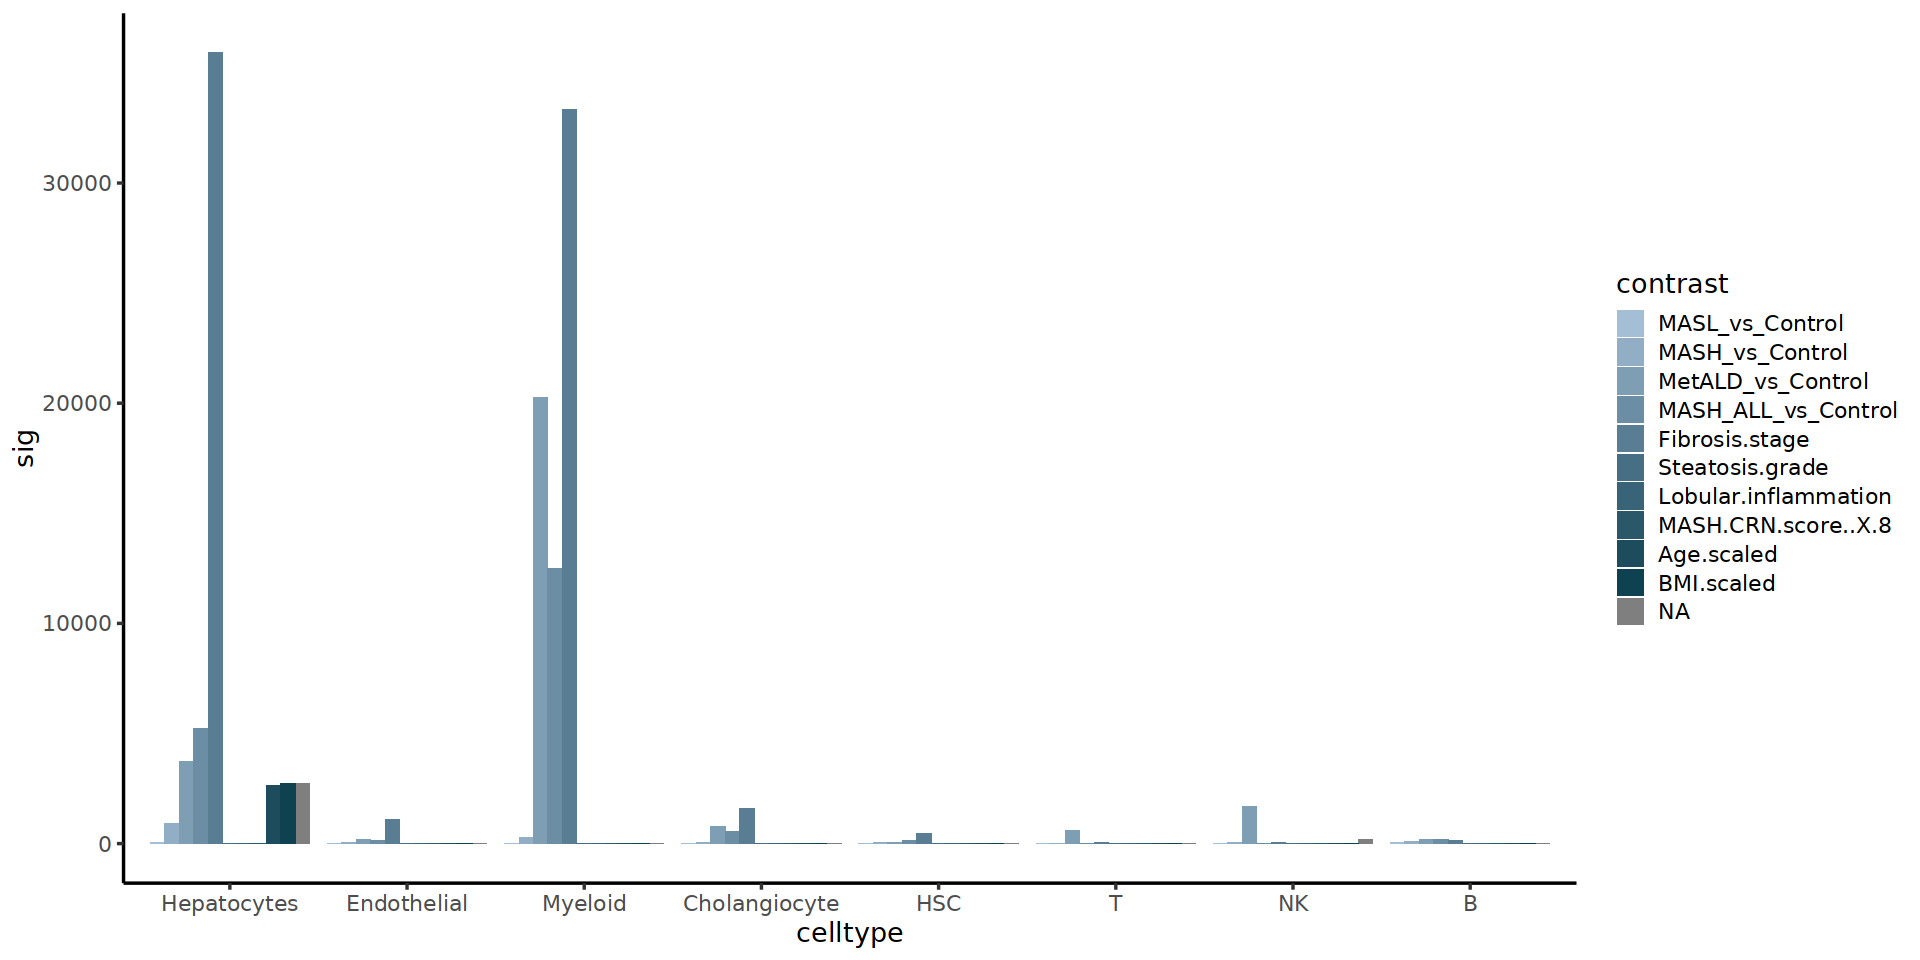

In [69]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    #scale_y_log10() +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(unique(deseq.stats2$contrast))))

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


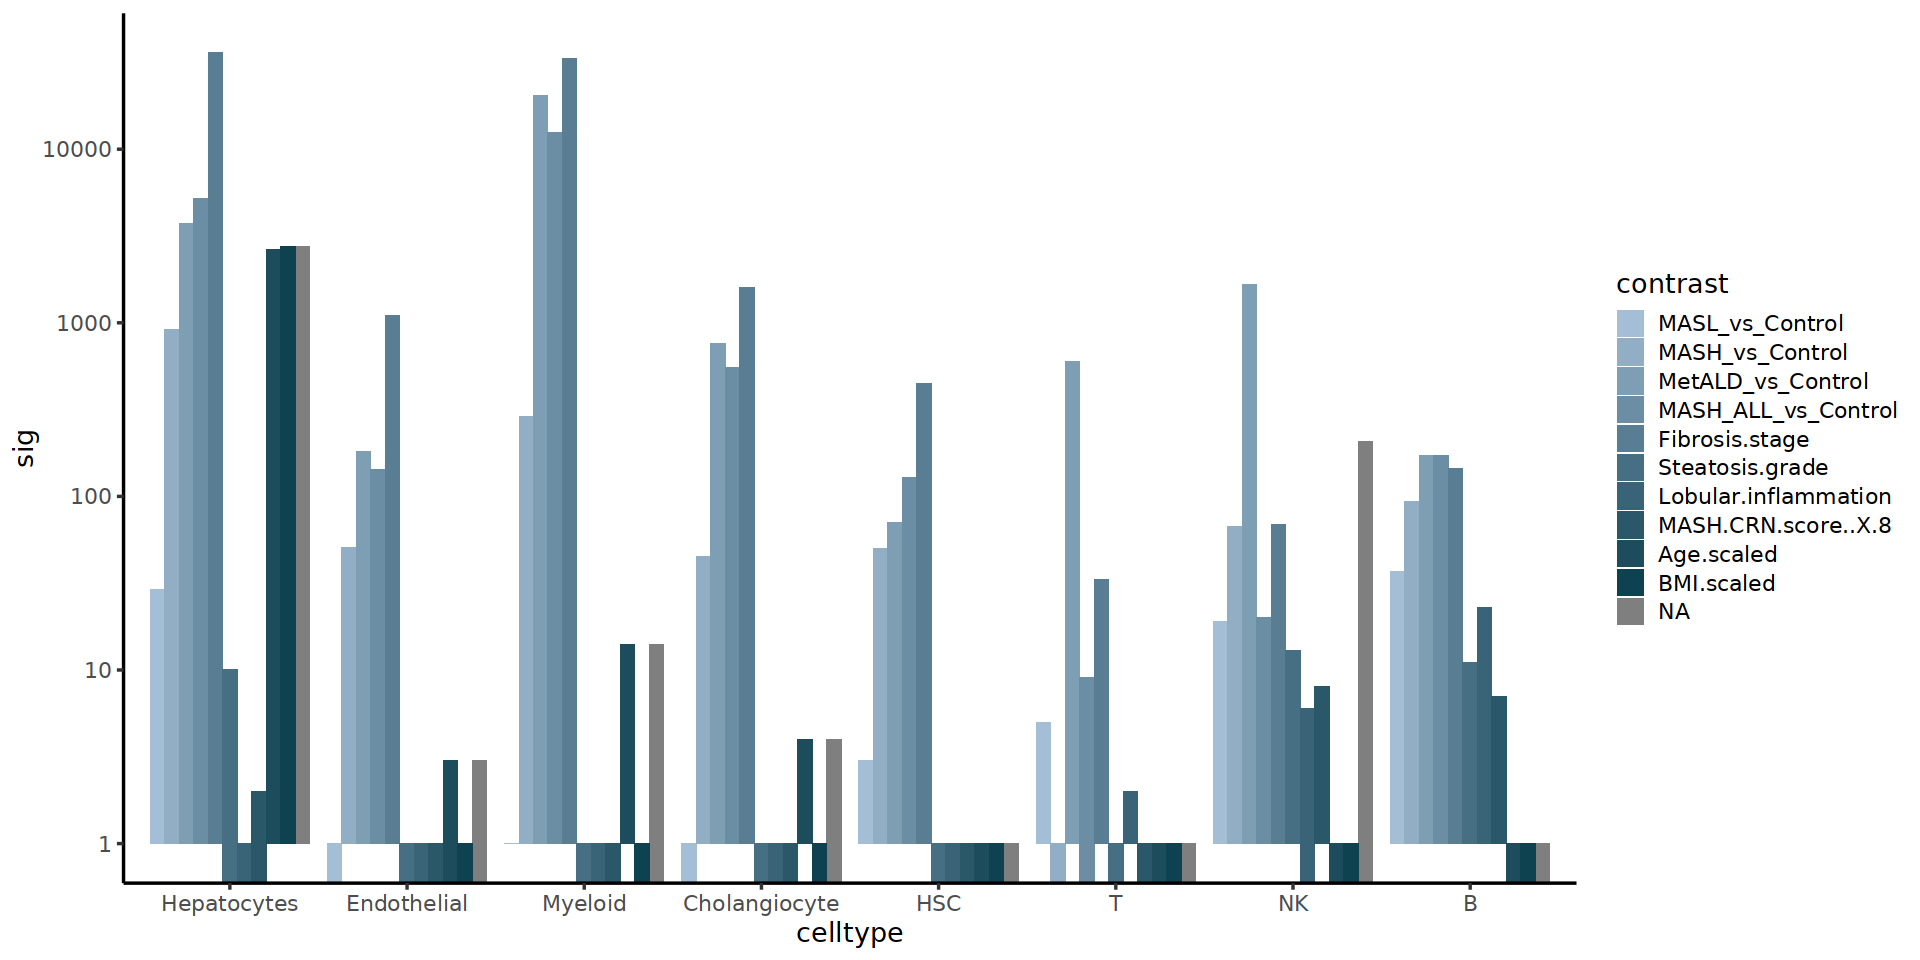

In [68]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    scale_y_log10() +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(unique(deseq.stats2$contrast))))

In [47]:
length(unique(deseq.stats2$contrast))

[1] 9

In [48]:
contrasts  <- c('Age','Age.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + BMI.scaled + batch + Gender'

In [49]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            if (is.null(nrow(raw_counts_subset))) {
                next
            }
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
            
            if (nrow(counts_filtered) < 3) {
                next
            }

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: B"
[1] 183028     37


Donors detectected with celltype: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Cholangiocyte"
[1] 183028     83


Donors detectected with celltype: 83

Subsetting metadata accordingly - Check that value is equal to above: 83

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Endothelial"
[1] 183028     86


...

Donors detectected with celltype: 56

Subsetting metadata accordingly - Check that value is equal to above: 56

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Schwann"
[1] 183028      0


Donors detectected with celltype: 0



[1] "Analyzing: T"
[1] 183028     68


Donors detectected with celltype: 68

Subsetting metadata accordingly - Check that value is equal to above: 68

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [50]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,3118,1043,3,37
B,MASH_vs_Control,7523,931,94,1
B,MetALD_vs_Control,3585,1144,173,134
Cholangiocyte,MASL_vs_Control,1836,3229,0,1
Cholangiocyte,MASH_vs_Control,2860,3020,15,45
Cholangiocyte,MetALD_vs_Control,2733,5530,143,759
Endothelial,MASL_vs_Control,3733,2688,0,0
Endothelial,MASH_vs_Control,5797,2650,51,16
Endothelial,MetALD_vs_Control,6308,5544,61,181


In [51]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
B,40,95,307,175,151,14,33,13,NA,0,1
Cholangiocyte,1,60,902,752,2760,1,1,0,NA,5,5
Endothelial,0,67,242,239,1955,0,0,0,NA,3,3
Hepatocytes,32,1373,6825,8465,51656,10,0,2,NA,5050,5050
HSC,4,73,86,243,742,0,0,0,NA,0,0
Myeloid,2,464,23747,15043,39880,0,0,1,NA,15,15
NK,22,72,1678,21,74,14,6,10,239,0,1
T,9,1,662,9,39,1,3,1,NA,0,0


In [52]:
deseq.stats2 <- deseq.stats

In [53]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

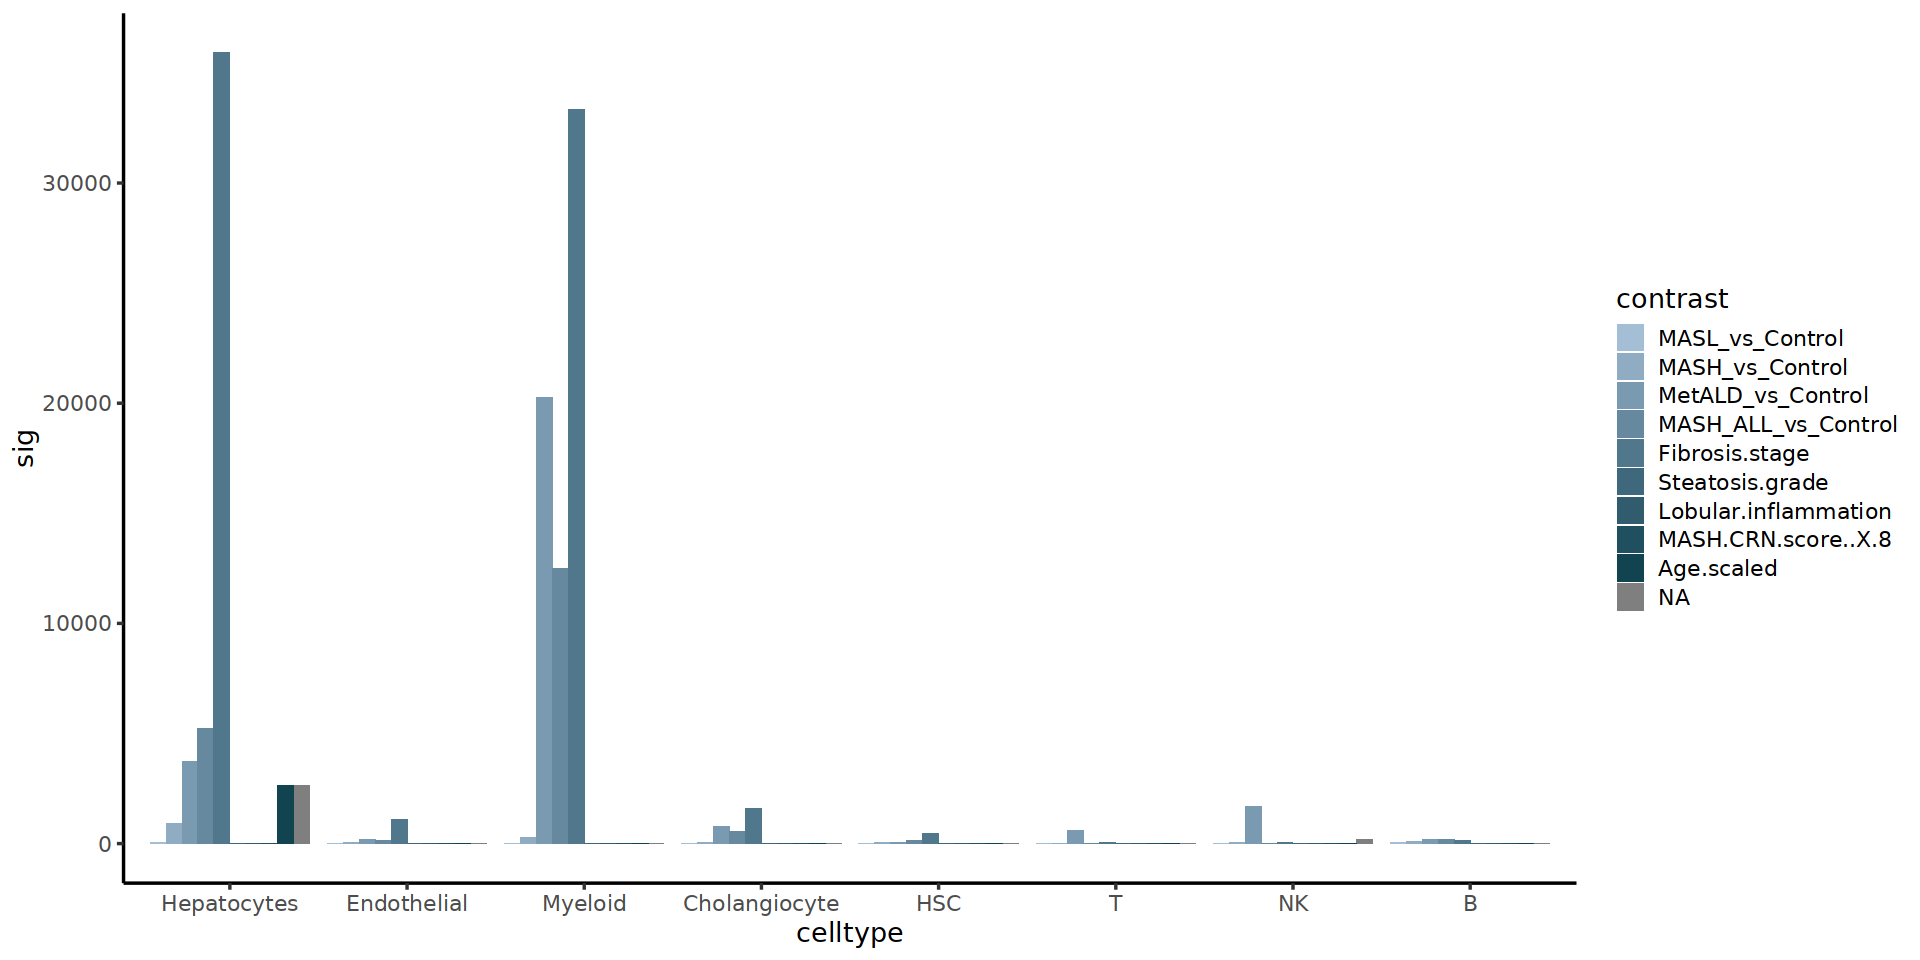

In [54]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [55]:
contrasts  <- c('BMI','BMI.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + batch + Gender'

In [56]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            if (is.null(nrow(raw_counts_subset))) {
                next
            }
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
            
            if (nrow(counts_filtered) < 3) {
                next
            }

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: B"
[1] 183028     37


Donors detectected with celltype: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Cholangiocyte"
[1] 183028     83


Donors detectected with celltype: 83

Subsetting metadata accordingly - Check that value is equal to above: 83

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Endothelial"
[1] 183028     86


...

Donors detectected with celltype: 56

Subsetting metadata accordingly - Check that value is equal to above: 56

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Schwann"
[1] 183028      0


Donors detectected with celltype: 0



[1] "Analyzing: T"
[1] 183028     68


Donors detectected with celltype: 68

Subsetting metadata accordingly - Check that value is equal to above: 68

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [57]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,3118,1043,3,37
B,MASH_vs_Control,7523,931,94,1
B,MetALD_vs_Control,3585,1144,173,134
Cholangiocyte,MASL_vs_Control,1836,3229,0,1
Cholangiocyte,MASH_vs_Control,2860,3020,15,45
Cholangiocyte,MetALD_vs_Control,2733,5530,143,759
Endothelial,MASL_vs_Control,3733,2688,0,0
Endothelial,MASH_vs_Control,5797,2650,51,16
Endothelial,MetALD_vs_Control,6308,5544,61,181


In [58]:
filter(deseq.stats, celltype=='Hepatocytes')

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes,MASL_vs_Control,4363,11691,3,29
Hepatocytes,MASH_vs_Control,11458,5688,917,456
Hepatocytes,MetALD_vs_Control,11636,10658,3739,3086
Hepatocytes,MASH_ALL_vs_Control,15583,10055,5216,3249
Hepatocytes,Fibrosis.stage,42564,18540,35914,15742
Hepatocytes,Steatosis.grade,2266,8214,0,10
Hepatocytes,Lobular.inflammation,2325,4355,0,0
Hepatocytes,MASH.CRN.score..X.8,2521,5648,0,2
Hepatocytes,Age,11713,8432,2411,2639


In [59]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
B,40,95,307,175,151,14,33,13,NA,0,1,0,0
Cholangiocyte,1,60,902,752,2760,1,1,0,NA,5,5,0,0
Endothelial,0,67,242,239,1955,0,0,0,NA,3,3,1,1
Hepatocytes,32,1373,6825,8465,51656,10,0,2,NA,5050,5050,4555,4555
HSC,4,73,86,243,742,0,0,0,NA,0,0,0,0
Myeloid,2,464,23747,15043,39880,0,0,1,NA,15,15,0,0
NK,22,72,1678,21,74,14,6,10,239,0,1,0,0
T,9,1,662,9,39,1,3,1,NA,0,0,0,0


In [60]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
B,40,95,307,175,151,14,33,13,NA,0,1,0,0
Cholangiocyte,1,60,902,752,2760,1,1,0,NA,5,5,0,0
Endothelial,0,67,242,239,1955,0,0,0,NA,3,3,1,1
Hepatocytes,32,1373,6825,8465,51656,10,0,2,NA,5050,5050,4555,4555
HSC,4,73,86,243,742,0,0,0,NA,0,0,0,0
Myeloid,2,464,23747,15043,39880,0,0,1,NA,15,15,0,0
NK,22,72,1678,21,74,14,6,10,239,0,1,0,0
T,9,1,662,9,39,1,3,1,NA,0,0,0,0


In [61]:
deseq.stats2 <- deseq.stats

In [62]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

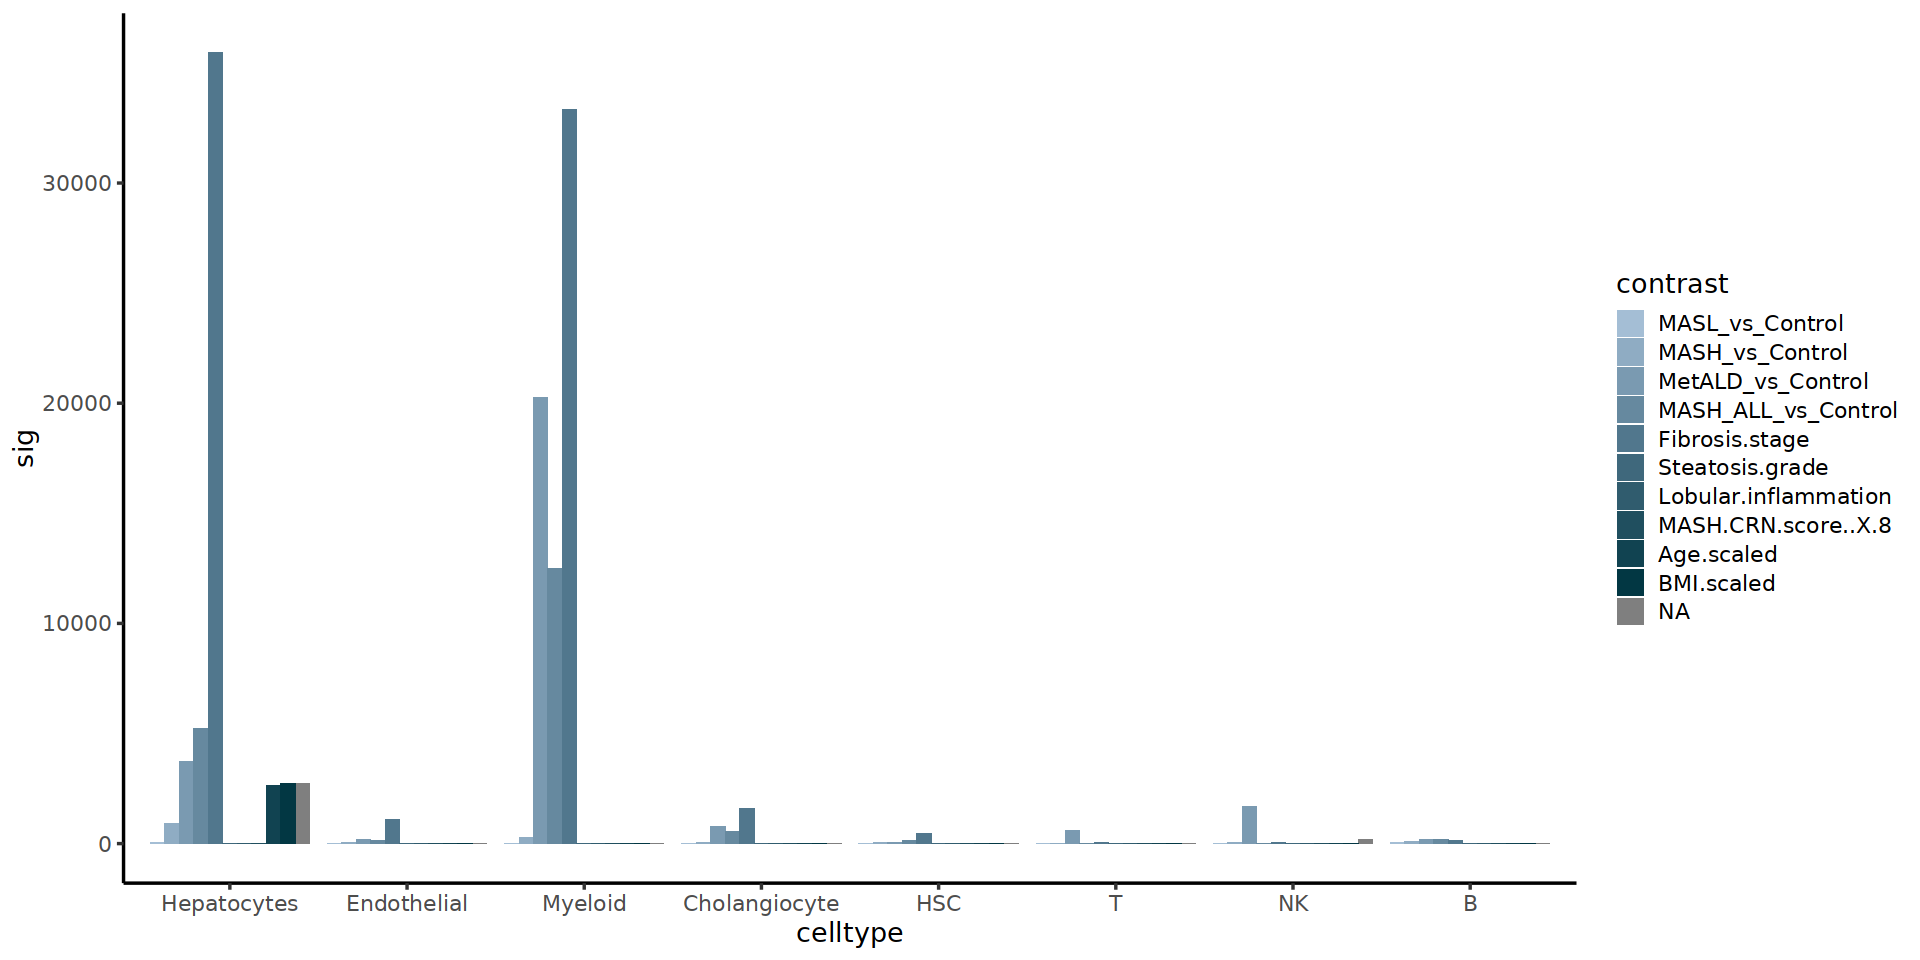

In [63]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [64]:
write.table(deseq.stats, paste0(outdir, '241024_WE_deseq_summary_add_contrasts_v2.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

In [65]:
deseq.stats2 <- deseq.stats
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

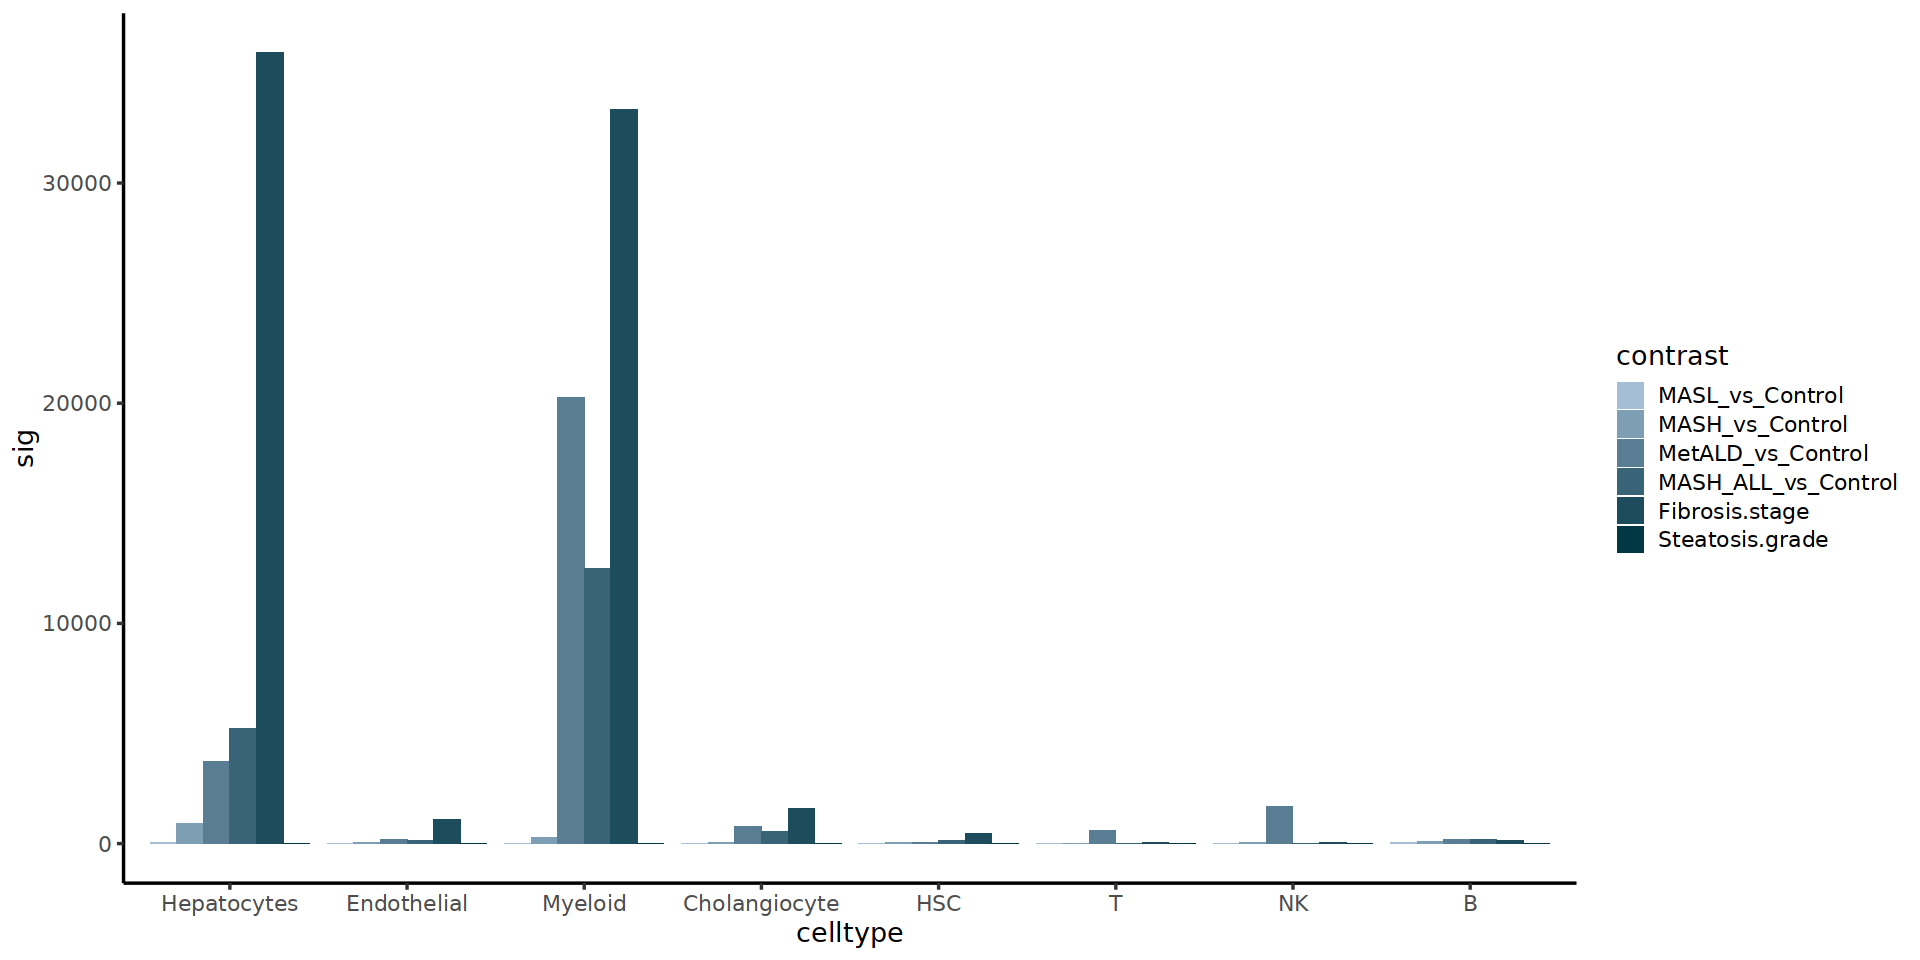

In [66]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
       filter(contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',
                             'Fibrosis.stage','Steatosis.grade','MASH_ALL_vs_Control')) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(6))

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


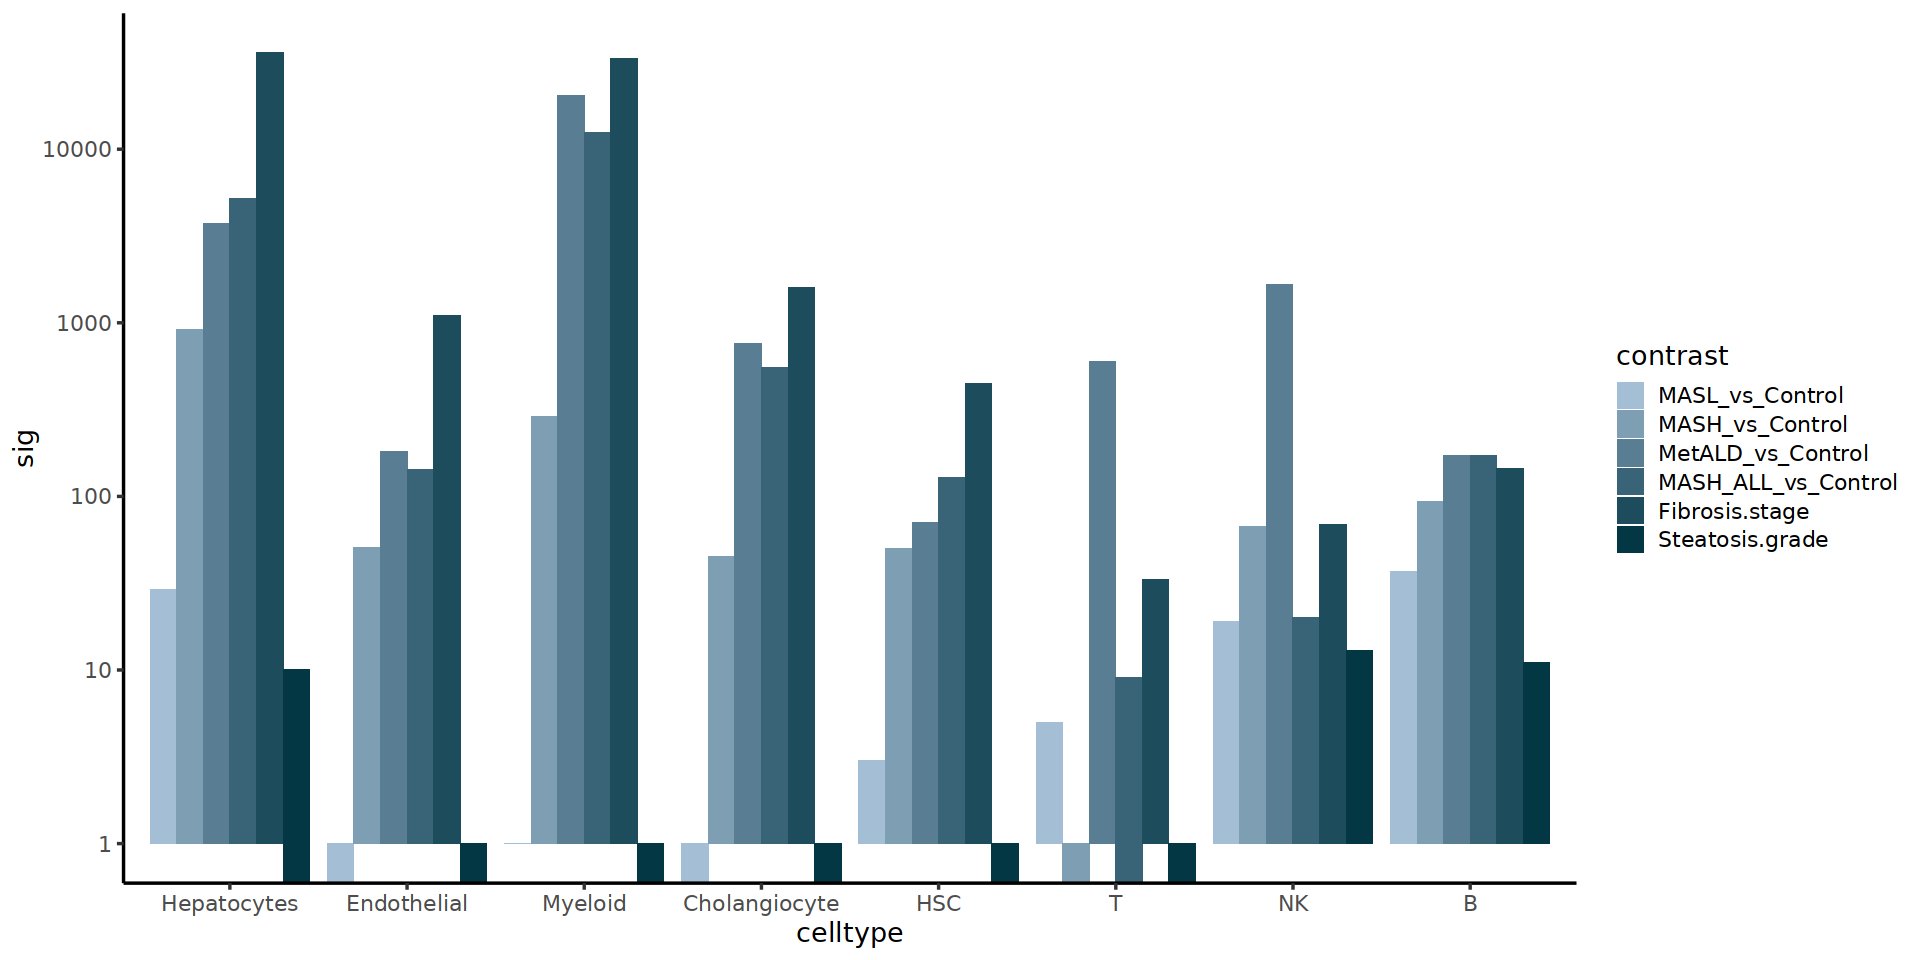

In [70]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
       filter(contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',
                             'Fibrosis.stage','Steatosis.grade','MASH_ALL_vs_Control')) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    scale_y_log10() +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(6))